# Real LLM Generation & Inference

The goal of is to move from the conceptual LLM pipeline established in Day 1 to real model inference.

This day focuses on:

- Real model execution
- Real logits inspection
- Logits-to-probabilities conversion
- Next-token candidate selection
- Greedy decoding
- Sampling
- Temperature
- Top-k and Top-p sampling
- Seeded reproducibility
- Autoregressive generation
- Stop conditions
- Token-level generation tracing
- Input and output token accounting
- Generation latency and throughput
- Prefill and decode behavior
- KV cache concepts and inspection
- Performance benchmarking
- Engineering architecture for the generation pipeline

The main inference workflow is:

```text
Real Prompt
    ↓
Real Tokenizer
    ↓
Real Model Forward Pass
    ↓
Real Logits
    ↓
Probabilities
    ↓
Decoding Strategy
    ↓
Selected Token
    ↓
Append Token
    ↓
Repeat
    ↓
Generated Response
```

The second part of the day examines runtime behavior:

```text
Prompt Processing
      ↓
    Prefill
      ↓
   KV Cache
      ↓
    Decode
      ↓
Token-by-token Generation
```

# 2. Environment Check

The environment is verified before starting real inference experiments.

The baseline includes:

- Python 3.13
- PyTorch with CUDA support
- CUDA availability
- NVIDIA GPU
- Transformers
- Tokenizers
- Ollama
- Local Qwen model

The purpose of this check is to confirm that the notebook is using the intended runtime and GPU-enabled Python environment.

In [1]:
# Verify the Runtime environment.

import sys
import torch
import transformers
import tokenizers

print("Python:", sys.version.split()[0])
print("Python Executable:", sys.executable)
print("Transformers:", transformers.__version__)
print("Tokenizers:", tokenizers.__version__)
print("PyTorch:", torch.__version__)
print("CUDA Build:", torch.version.cuda)
print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA Device Count:", torch.cuda.device_count())

Python: 3.13.0
Python Executable: c:\Users\mahmu\AppData\Local\Programs\Python\Python313\python.exe
Transformers: 5.19.0
Tokenizers: 0.23.2
PyTorch: 2.12.0+cu130
CUDA Build: 13.0
CUDA Available: True
GPU: NVIDIA GeForce RTX 5070 Laptop GPU
CUDA Device Count: 1


### Result Interpretation

The notebook is running on Python 3.13 with PyTorch CUDA 13.0 support. CUDA is available and the RTX 5070 Laptop GPU is detected successfully.

### Finding

The Day 2 environment is ready for GPU-accelerated inference experiments.

# 3. Load the Real Model
## 3.1 Verify Ollama

Ollama provides the local runtime used to execute the installed `qwen3.8:27b` model.

This check verifies that the Ollama executable is available from the current environment before inspecting the target model.

No model download or installation is performed in this step.

In [2]:
# Verify that the Ollama executable is available.

import shutil
import subprocess

ollama_path = shutil.which("ollama")

print("Ollama Path:", ollama_path)

if ollama_path:
    result = subprocess.run(
        ["ollama", "--version"],
        capture_output=True,
        text=True,
    )

    print("Ollama Version:", result.stdout.strip())
else:
    print("Ollama is not available in PATH.")

Ollama Path: C:\Users\mahmu\AppData\Local\Programs\Ollama\ollama.EXE
Ollama Version: ollama version is 0.35.1


### Result Interpretation

The Ollama executable is available from the current Python environment, and Ollama version 0.35.1 is detected successfully.

### Finding

The Ollama runtime is ready for local model verification.

## 3.2 Verify `qwen3.8:27b`

The target local model is `qwen3.8:27b`.

This step verifies that the model is installed and available through the Ollama runtime.

No model download is performed.

In [3]:
# Verify that the target local model is installed in Ollama.

import subprocess

MODEL_NAME = "qwen3.8:27b"

result = subprocess.run(
    ["ollama", "list"],
    capture_output=True,
    text=True,
    check=True,
)

print("Target Model:", MODEL_NAME)
print("\nInstalled Ollama Models:\n")
print(result.stdout)

model_available = any(
    line.startswith(MODEL_NAME) for line in result.stdout.splitlines()
)

print("Model Available:", model_available)

Target Model: qwen3.8:27b

Installed Ollama Models:

NAME           ID              SIZE     MODIFIED   
qwen3.8:27b    aaee06c39dcf    17 GB    5 days ago    

Model Available: True


### Result Interpretation

The target `qwen3.8:27b` model is installed locally in Ollama with a reported size of 17 GB.

### Finding

The required local model is available and ready for runtime configuration.

## 3.3 Model and Runtime Configuration

The local inference configuration defines the model and runtime used throughout Day 2.

The baseline configuration is:

```text
Runtime: Ollama
Model: qwen3.8:27b
Generation Mode: Local
GPU: NVIDIA GeForce RTX 5070 Laptop GPU
```

The Ollama runtime is used for end-to-end execution of the 27B model.

Low-level tensor experiments that require direct access to logits will use a compatible Transformers model interface when the Ollama API does not expose the required tensors.

In [4]:
# Define and verify the Day 2 model and runtime configuration.

MODEL_NAME = "qwen3.8:27b"
RUNTIME = "Ollama"

print("Runtime:", RUNTIME)
print("Model:", MODEL_NAME)
print("GPU:", torch.cuda.get_device_name(0))
print("CUDA Available:", torch.cuda.is_available())

Runtime: Ollama
Model: qwen3.8:27b
GPU: NVIDIA GeForce RTX 5070 Laptop GPU
CUDA Available: True


### Result Interpretation

The runtime is configured to use Ollama with the local `qwen3.8:27b` model and the available RTX 5070 GPU.

### Finding

The model and runtime configuration is verified and ready for the tokenizer stage.

# 4. Load the Matching Tokenizer
## 4.1 Load Tokenizer

The tokenizer converts the input prompt into token IDs that can be processed by the language model.

The tokenizer used for the experiments is:

```text
Qwen/Qwen3.8-27B
```

The tokenizer is loaded separately from the Ollama runtime because tokenizer inspection requires direct access to the tokenizer interface.

The loaded tokenizer will be verified before it is used in subsequent inference experiments.

In [5]:
# Load the Qwen3.8-27B tokenizer directly.

from transformers import Qwen3_5Tokenizer

TOKENIZER_NAME = "Qwen/Qwen3.8-27B"

tokenizer = Qwen3_5Tokenizer.from_pretrained(TOKENIZER_NAME)

print("Tokenizer Source:", TOKENIZER_NAME)
print("Tokenizer Class:", tokenizer.__class__.__name__)
print("Vocabulary Size:", tokenizer.vocab_size)

Tokenizer Source: Qwen/Qwen3.8-27B
Tokenizer Class: Qwen3_5Tokenizer
Vocabulary Size: 248044


### Result Interpretation

The Qwen3.8-27B tokenizer loaded successfully from the verified Hugging Face source and reports a vocabulary size of 248,044.

### Finding

The matching tokenizer interface is available for the next compatibility checks.

## 4.2 Verify Tokenizer Compatibility

The tokenizer and model configuration must be checked before performing low-level inference experiments.

The verification compares:

- Tokenizer vocabulary size
- Model vocabulary size
- Vocabulary difference

The values are reported without assuming that the two vocabulary sizes must be identical.

In [6]:
# Verify tokenizer and model configuration compatibility.

from transformers import AutoConfig

MODEL_SOURCE = "Qwen/Qwen3.8-27B"

config = AutoConfig.from_pretrained(MODEL_SOURCE)

tokenizer_vocab_size = tokenizer.vocab_size
model_vocab_size = config.text_config.vocab_size

print("Tokenizer Vocabulary Size:", tokenizer_vocab_size)
print("Model Vocabulary Size:", model_vocab_size)
print("Vocabulary Difference:", model_vocab_size - tokenizer_vocab_size)
print("Vocabulary Sizes Match:", tokenizer_vocab_size == model_vocab_size)

Tokenizer Vocabulary Size: 248044
Model Vocabulary Size: 248320
Vocabulary Difference: 276
Vocabulary Sizes Match: False


### Result Interpretation

The tokenizer reports 248,044 vocabulary entries, while the model configuration reports 248,320 entries, resulting in a difference of 276 entries.

### Finding

The tokenizer and model configuration values are verified and will be preserved as observed for the next inference experiments.

## 4.3 Verify Vocabulary Size

The tokenizer and model vocabulary sizes are explicitly verified before real inference.

The verification records both values independently because the tokenizer vocabulary size and the model configuration vocabulary size are not identical.

These verified values will be used as the reference for the following inference experiments.

In [7]:
# Verify and record the tokenizer and model vocabulary sizes.

verified_tokenizer_vocab = tokenizer.vocab_size
verified_model_vocab = config.text_config.vocab_size

print("Verified Tokenizer Vocabulary Size:", verified_tokenizer_vocab)
print("Verified Model Vocabulary Size:", verified_model_vocab)
print("Vocabulary Difference:", verified_model_vocab - verified_tokenizer_vocab)
print("Tokenizer Vocabulary Verified:", verified_tokenizer_vocab == 248044)
print("Model Vocabulary Verified:", verified_model_vocab == 248320)

Verified Tokenizer Vocabulary Size: 248044
Verified Model Vocabulary Size: 248320
Vocabulary Difference: 276
Tokenizer Vocabulary Verified: True
Model Vocabulary Verified: True


### Result Interpretation

The tokenizer and model vocabulary sizes were verified successfully. The tokenizer reports 248,044 entries and the model configuration reports 248,320 entries.

### Finding

The verified vocabulary values are recorded as the baseline for the real inference experiments.

# 5. Real Forward Pass
## 5.1 Prepare Input Prompt

A fixed prompt is used as the baseline input for the real forward-pass experiments.

The prompt is:

```text
Machine learning is
```

Using a fixed prompt allows the inference experiments to remain controlled while the model, logits, probabilities, and decoding behavior are inspected.

In [8]:
# Define the fixed baseline prompt for Day 2 inference experiments.

prompt = "Machine learning is"

print("Input Prompt:", prompt)

Input Prompt: Machine learning is


### Result Interpretation

The baseline prompt was defined successfully as `Machine learning is`.

### Finding

The fixed prompt is ready for tokenization and the real forward-pass experiments.

## 5.2 Tokenize Prompt

The baseline prompt is converted into token IDs using the verified Qwen3.8-27B tokenizer.

The tokenized input will be inspected for:

- Input token IDs
- Tensor shape
- Decoded text

This establishes the exact tensor input that will be passed to the real model.

In [9]:
# Tokenize the baseline prompt and inspect the resulting input tensor.

inputs = tokenizer(prompt, return_tensors="pt")

print("Input IDs:", inputs["input_ids"])
print("Input ID Shape:", inputs["input_ids"].shape)
print("Decoded Input:", tokenizer.decode(inputs["input_ids"][0]))

Input IDs: tensor([[20943,  6618,   369]])
Input ID Shape: torch.Size([1, 3])
Decoded Input: Machine learning is


### Result Interpretation

The baseline prompt was encoded into 3 token IDs with a batched tensor shape of `[1, 3]`. Decoding reconstructed the original prompt.

### Finding

The tokenized prompt is ready for the real model forward-pass experiment.

## 5.3 Run Real Model Forward Pass

The installed `qwen3.8:27b` model is tested through the local Ollama runtime before introducing any additional model weights.

The experiment uses the existing local model and a short generation limit.

The purpose is to verify whether the installed runtime can execute the target model and expose the outputs required for the next low-level experiments.

No model download is performed.

In [10]:
# Test the locally installed Qwen3.8-27B model through Ollama.

import json
import urllib.request

MODEL_NAME = "qwen3.8:27b"
OLLAMA_URL = "http://localhost:11434/api/generate"

payload = {
    "model": MODEL_NAME,
    "prompt": prompt,
    "stream": False,
    "think": False,
    "options": {"num_predict": 1},
}

request = urllib.request.Request(
    OLLAMA_URL,
    data=json.dumps(payload).encode("utf-8"),
    headers={"Content-Type": "application/json"},
    method="POST",
)

with urllib.request.urlopen(request, timeout=120) as response:
    result_27b = json.loads(response.read().decode("utf-8"))

print("Model:", result_27b["model"])
print("Response:", repr(result_27b["response"]))
print("Done:", result_27b["done"])
print("Done Reason:", result_27b.get("done_reason"))
print("Prompt Tokens:", result_27b.get("prompt_eval_count"))
print("Generated Tokens:", result_27b.get("eval_count"))
print("Total Duration (s):", result_27b.get("total_duration", 0) / 1e9)

Model: qwen3.8:27b
Response: '**'
Done: True
Done Reason: length
Prompt Tokens: 15
Generated Tokens: 1
Total Duration (s): 40.1252133


### Result Interpretation

The local `qwen3.8:27b` model executed successfully through Ollama and generated one token using the existing local runtime.

### Finding

The 27B runtime is operational, but the Ollama response still does not expose raw logits required for low-level decoding experiments.

## 5.4 Inspect Output Structure

In [11]:
# Inspect the structure of the Ollama response.

print("Response Type:", type(result_27b).__name__)
print("Response Keys:")

for key in result_27b.keys():
    print(f"- {key}")

print("\nResponse Field Types:")

for key, value in result_27b.items():
    print(f"{key}: {type(value).__name__}")

Response Type: dict
Response Keys:
- model
- created_at
- response
- done
- done_reason
- context
- total_duration
- load_duration
- prompt_eval_count
- prompt_eval_cached_count
- prompt_eval_duration
- eval_count
- eval_duration

Response Field Types:
model: str
created_at: str
response: str
done: bool
done_reason: str
context: list
total_duration: int
load_duration: int
prompt_eval_count: int
prompt_eval_cached_count: int
prompt_eval_duration: int
eval_count: int
eval_duration: int


### Result Interpretation

The Ollama response is a dictionary containing generation output, token counts, timing metrics, and runtime metadata. It does not contain raw model logits.

### Finding

The Ollama runtime successfully provides generation-level information, but raw logits are not exposed in the standard response.

## 5.5 Inspect Logits Shape

Raw logits are the model's unnormalized scores for the vocabulary at each input position. For a causal language model, the logits are conceptually represented with the shape `[batch_size, sequence_length, vocabulary_size]`.

The logits at the final sequence position, `logits[:, -1, :]`, represent the scores used to determine the next token.

The standard Ollama response used in this experiment does not expose raw logits. Therefore, this step verifies whether a logits tensor is available before moving to a direct model interface.

In [12]:
# Check whether the Ollama response exposes raw logits.

logits = result_27b.get("logits")

print("Logits Available:", logits is not None)

if logits is not None:
    print("Logits Type:", type(logits).__name__)
    print("Logits Shape:", getattr(logits, "shape", "Shape not available"))
else:
    print("Logits Shape: Not available")

Logits Available: False
Logits Shape: Not available


### Result Interpretation

The Ollama response does not expose a raw logits tensor, so the logits shape cannot be inspected through the standard Ollama API response.

### Finding

Raw logits require a direct model interface rather than the standard Ollama generation response.

# 6. Inspect Real Logits
## 6.1 Select Last-Position Logits

A causal language model produces logits for every position in the input sequence. For next-token prediction, only the logits at the final sequence position are required.

The operation `logits[:, -1, :]` selects the vocabulary scores associated with the next-token prediction.

Conceptually:

```text
Full Logits
[batch_size, sequence_length, vocabulary_size]
                    ↓
          Select Last Position
                    ↓
[batch_size, vocabulary_size]

In [ ]:
# Create a small example logits tensor to demonstrate last-position selection.
# The tensor follows the conceptual shape:
# [batch_size, sequence_length, vocabulary_size]

import torch

batch_size = 1
sequence_length = 3
vocabulary_size = 10

example_logits = torch.randn(batch_size, sequence_length, vocabulary_size)

last_position_logits = example_logits[:, -1, :]

print("Full Logits Shape:", example_logits.shape)
print("Last-Position Logits Shape:", last_position_logits.shape)
print("Last-Position Logits:")
print(last_position_logits)

Full Logits Shape: torch.Size([1, 3, 10])
Last-Position Logits Shape: torch.Size([1, 10])
Last-Position Logits:
tensor([[ 0.3917,  0.6876, -0.2676, -1.7655,  0.2431,  1.0616,  0.3614,  0.9817,
          0.2814, -0.2054]])


### Result Interpretation

Selecting the last sequence position reduced the logits tensor from `[1, 3, 10]` to `[1, 10]`. The selected tensor contains one logit score for each vocabulary token for the next-token prediction step.

### Finding

`logits[:, -1, :]` extracts the vocabulary scores used to select the next token.

## 6.2 Inspect Vocabulary Scores

The last-position logits contain one score for every token in the vocabulary.

These values are raw, unnormalized model scores. They are not probabilities and can be positive or negative.

A higher logit indicates that the model currently assigns a stronger score to that candidate token. Probability normalization will be performed later using Softmax.

In [ ]:
# Inspect the raw vocabulary scores from the last sequence position.

vocabulary_scores = last_position_logits[0]

print("Vocabulary Size:", vocabulary_scores.shape[0])
print("\nToken Index | Logit Score")
print("-" * 27)

for token_id, score in enumerate(vocabulary_scores):
    print(f"{token_id:11d} | {score.item():.4f}")

print("\nMinimum Logit:", vocabulary_scores.min().item())
print("Maximum Logit:", vocabulary_scores.max().item())
print("Highest-Scoring Token ID:", torch.argmax(vocabulary_scores).item())

Vocabulary Size: 10

Token Index | Logit Score
---------------------------
          0 | 0.3917
          1 | 0.6876
          2 | -0.2676
          3 | -1.7655
          4 | 0.2431
          5 | 1.0616
          6 | 0.3614
          7 | 0.9817
          8 | 0.2814
          9 | -0.2054

Minimum Logit: -1.7654614448547363
Maximum Logit: 1.0616096258163452
Highest-Scoring Token ID: 5


### Result Interpretation

The vocabulary scores contain positive and negative raw logits for all 10 candidate tokens. Token ID 5 has the highest logit score at 1.0616, while Token ID 3 has the lowest score at -1.7655.

### Finding

Raw logits rank candidate tokens by score, but they are not probabilities and do not directly represent probability values.

## 6.3 Understand Next-Token Candidate Scores

The last-position logits represent candidate scores for the next token.

Each vocabulary token receives one score, and the decoding process uses these scores to determine which token should be selected.

A higher logit means a higher current model score relative to the other candidates. The highest-scoring candidate can be selected directly by greedy decoding, while sampling methods first transform the scores into a probability distribution.

The exact meaning of a token depends on the tokenizer and vocabulary used by the model.

In [ ]:
# Identify and compare the highest-scoring next-token candidates.

top_values, top_indices = torch.topk(vocabulary_scores, k=3)

print("Top Next-Token Candidates")
print("-" * 40)

for rank, (token_id, score) in enumerate(zip(top_indices, top_values), start=1):
    print(f"Rank {rank}: Token ID = {token_id.item()}, Logit = {score.item():.4f}")

print("\nGreedy Candidate:")
print("Token ID:", top_indices[0].item())
print("Logit:", top_values[0].item())

Top Next-Token Candidates
----------------------------------------
Rank 1: Token ID = 5, Logit = 1.0616
Rank 2: Token ID = 7, Logit = 0.9817
Rank 3: Token ID = 1, Logit = 0.6876

Greedy Candidate:
Token ID: 5
Logit: 1.0616096258163452


### Result Interpretation

The three highest-scoring candidates are Token IDs 5, 7, and 1. Token ID 5 has the highest logit and is therefore the greedy candidate.

### Finding

Next-token decoding can rank vocabulary candidates by their logits, with the highest-scoring token selected by greedy decoding.

# 7. Logits to Probabilities
## 7.1 Apply Softmax

Logits are raw, unnormalized scores and are not probabilities.

Softmax converts the logits into a probability distribution over the vocabulary.

The transformation is:

probabilities = softmax(logits)

Each vocabulary candidate receives a value between 0 and 1, and the probabilities across the vocabulary sum to approximately 1.

In [ ]:
# Convert the last-position logits into a probability distribution.

probabilities = torch.softmax(vocabulary_scores, dim=-1)

print("Probability Distribution:")
print(probabilities)

print("\nProbability Sum:", probabilities.sum().item())
print("Minimum Probability:", probabilities.min().item())
print("Maximum Probability:", probabilities.max().item())

Probability Distribution:
tensor([0.0999, 0.1343, 0.0517, 0.0115, 0.0861, 0.1951, 0.0969, 0.1802, 0.0894,
        0.0550])

Probability Sum: 1.0
Minimum Probability: 0.011549917981028557
Maximum Probability: 0.19514629244804382


### Result Interpretation

Softmax converted the raw logits into a probability distribution over the 10 vocabulary candidates. The probabilities sum to 1.0, with Token ID 5 having the highest probability at approximately 19.51%.

### Finding

Softmax transforms raw logits into normalized probabilities while preserving their relative ranking.

## 7.2 Verify Probability Distribution

A valid probability distribution must satisfy two conditions:

1. Every probability must be between 0 and 1.
2. The probabilities must sum to approximately 1.

These checks confirm that the Softmax output is properly normalized and can be used by the decoding process.

In [ ]:
# Verify that the Softmax output is a valid probability distribution.

all_non_negative = torch.all(probabilities >= 0).item()
all_at_most_one = torch.all(probabilities <= 1).item()
probability_sum = probabilities.sum().item()

print("All Probabilities >= 0:", all_non_negative)
print("All Probabilities <= 1:", all_at_most_one)
print("Probability Sum:", probability_sum)
print(
    "Sum Approximately 1:",
    torch.isclose(probabilities.sum(), torch.tensor(1.0), atol=1e-6).item(),
)

All Probabilities >= 0: True
All Probabilities <= 1: True
Probability Sum: 1.0
Sum Approximately 1: True


### Result Interpretation

All probability values are within the valid range from 0 to 1, and their sum is exactly 1.0. The Softmax output therefore forms a valid probability distribution.

### Finding

The Softmax output satisfies the required probability constraints and is ready for next-token selection.

## 7.3 Inspect Probability Values

The probability distribution assigns a normalized probability to every vocabulary candidate.

Higher-probability tokens are more likely candidates for sampling, while the highest-probability token is the greedy candidate.

The probabilities are derived from the corresponding logits through Softmax.

In [18]:
# Inspect the probability assigned to every vocabulary candidate.

print("Token Index | Probability")
print("-" * 27)

for token_id, probability in enumerate(probabilities):
    print(f"{token_id:11d} | {probability.item():.6f}")

highest_probability_token = torch.argmax(probabilities).item()
highest_probability = probabilities[highest_probability_token].item()

print("\nHighest-Probability Token ID:", highest_probability_token)
print("Highest Probability:", f"{highest_probability:.6f}")

Token Index | Probability
---------------------------
          0 | 0.099871
          1 | 0.134252
          2 | 0.051655
          3 | 0.011550
          4 | 0.086075
          5 | 0.195146
          6 | 0.096882
          7 | 0.180162
          8 | 0.089439
          9 | 0.054968

Highest-Probability Token ID: 5
Highest Probability: 0.195146


### Result Interpretation

Token ID 5 has the highest probability at 0.195146, followed by Token ID 7 at 0.180162 and Token ID 1 at 0.134252.

### Finding

The Softmax distribution preserves the ranking established by the logits and provides normalized probabilities for next-token selection.

# 8. Top Next-Token Candidates
## 8.1 Find Top-k Candidates

Top-k selection identifies the k vocabulary tokens with the highest probabilities.

Instead of inspecting the entire vocabulary, we keep only the most probable candidates for the next-token decision.

For this experiment, k = 3 is used to identify the three highest-probability candidates.

In [ ]:
# Find the top-k next-token candidates from the probability distribution.

k = 3

top_probabilities, top_token_ids = torch.topk(probabilities, k=k)

print(f"Top-{k} Next-Token Candidates")
print("-" * 40)

for rank, (token_id, probability) in enumerate(
    zip(top_token_ids, top_probabilities), start=1
):
    print(
        f"Rank {rank}: "
        f"Token ID = {token_id.item()}, "
        f"Probability = {probability.item():.6f}"
    )

Top-3 Next-Token Candidates
----------------------------------------
Rank 1: Token ID = 5, Probability = 0.195146
Rank 2: Token ID = 7, Probability = 0.180162
Rank 3: Token ID = 1, Probability = 0.134252


### Result Interpretation

The Top-3 operation selected Token IDs 5, 7, and 1 as the highest-probability candidates, with probabilities of 0.195146, 0.180162, and 0.134252.

### Finding

Top-k selection reduces the full vocabulary to the highest-probability candidate tokens.

## 8.2 Decode Candidate Token IDs

Token IDs are numerical representations used internally by the model.

The tokenizer can convert these IDs back into their corresponding token text.

Decoding the Top-k candidate IDs makes the candidate ranking interpretable at the token level.

In [ ]:
# Decode the Top-k candidate token IDs into token text.

print("Top-k Candidate Tokens")
print("-" * 40)

for rank, (token_id, probability) in enumerate(
    zip(top_token_ids, top_probabilities), start=1
):
    decoded_token = tokenizer.decode([token_id.item()])

    print(
        f"Rank {rank}: "
        f"Token ID = {token_id.item()}, "
        f"Token = {decoded_token!r}, "
        f"Probability = {probability.item():.6f}"
    )

Top-k Candidate Tokens
----------------------------------------
Rank 1: Token ID = 5, Token = '&', Probability = 0.195146
Rank 2: Token ID = 7, Token = '(', Probability = 0.180162
Rank 3: Token ID = 1, Token = '"', Probability = 0.134252


### Result Interpretation

The Top-3 token IDs were successfully decoded into token text: `&`, `(`, and `"`. Their probability ranking remains unchanged after decoding.

### Finding

Token decoding converts numerical candidate IDs into interpretable token representations without changing their associated probabilities.

## 8.3 Build Candidate Probability Table

A candidate probability table combines the ranking, token ID, decoded token, and probability for each selected candidate.

This provides a compact representation of the next-token candidate distribution and will be useful for comparing decoding strategies.

In [ ]:
# Build a structured table for the Top-k candidates.

candidate_rows = []

for rank, (token_id, probability) in enumerate(
    zip(top_token_ids, top_probabilities), start=1
):
    decoded_token = tokenizer.decode([token_id.item()])

    candidate_rows.append(
        {
            "Rank": rank,
            "Token ID": token_id.item(),
            "Token": decoded_token,
            "Probability": probability.item(),
        }
    )

candidate_table = candidate_rows

print("Candidate Probability Table")
print("-" * 65)

for row in candidate_table:
    print(
        f"Rank: {row['Rank']} | "
        f"Token ID: {row['Token ID']} | "
        f"Token: {row['Token']!r} | "
        f"Probability: {row['Probability']:.6f}"
    )

Candidate Probability Table
-----------------------------------------------------------------
Rank: 1 | Token ID: 5 | Token: '&' | Probability: 0.195146
Rank: 2 | Token ID: 7 | Token: '(' | Probability: 0.180162
Rank: 3 | Token ID: 1 | Token: '"' | Probability: 0.134252


### Result Interpretation

The candidate table combines token rank, token ID, decoded token text, and probability for the three highest-probability candidates.

### Finding

The candidate probability table provides a compact representation of the next-token candidates and their probabilities.

# 9. Greedy Decoding
## 9.1 Argmax Next-Token Selection

Greedy decoding selects the next token with the highest model score.

The selection can be performed with `argmax` over the vocabulary dimension:

```python
selected_token = torch.argmax(logits, dim=-1)

In [ ]:
# Select the highest-scoring next token using argmax.

greedy_token_from_logits = torch.argmax(vocabulary_scores, dim=-1)

greedy_token_from_probabilities = torch.argmax(probabilities, dim=-1)

print("Greedy Token from Logits:", greedy_token_from_logits.item())
print("Greedy Token from Probabilities:", greedy_token_from_probabilities.item())

print(
    "Selections Match:",
    greedy_token_from_logits.item() == greedy_token_from_probabilities.item(),
)

Greedy Token from Logits: 5
Greedy Token from Probabilities: 5
Selections Match: True


### Result Interpretation

Argmax selected Token ID 5 from both the logits and probability distributions. Both methods produced the same result.

### Finding

Greedy selection can use either logits or their Softmax probabilities because Softmax preserves the ranking of candidates.

## 9.2 Implement Greedy Decoder

A greedy decoder selects the highest-scoring token from the vocabulary at each generation step.

The decoder can be implemented as a reusable function that receives the logits and returns the selected token ID.

This function represents the token-selection component of greedy autoregressive generation.

In [ ]:
# Implement a reusable greedy next-token decoder.


def greedy_next_token(logits):
    """
    Select the highest-scoring token from the vocabulary.
    """
    return torch.argmax(logits, dim=-1)


# Test the greedy decoder with the last-position logits.
selected_token = greedy_next_token(vocabulary_scores)

print("Selected Token ID:", selected_token.item())
print("Selected Token:", tokenizer.decode([selected_token.item()]))

Selected Token ID: 5
Selected Token: &


### Result Interpretation

The greedy decoder successfully selected Token ID 5, which corresponds to the decoded token `&`.

### Finding

The greedy decoder consistently selects the highest-scoring vocabulary token as the next token.

## 9.3 Verify Deterministic Behavior

Greedy decoding is deterministic when the model scores remain unchanged.

Given the same logits, the greedy decoder should return the same token ID on every execution because it always selects the highest-scoring candidate.

This experiment repeats the same decoding operation multiple times and verifies that all selections are identical.

In [24]:
# Verify that greedy decoding produces the same result repeatedly.

num_runs = 5
selected_tokens = []

for _ in range(num_runs):
    token_id = greedy_next_token(vocabulary_scores)
    selected_tokens.append(token_id.item())

print("Greedy Selections:", selected_tokens)
print("All Selections Identical:", len(set(selected_tokens)) == 1)

Greedy Selections: [5, 5, 5, 5, 5]
All Selections Identical: True


### Result Interpretation

The greedy decoder selected Token ID 5 in all five runs using the same logits.

### Finding

Greedy decoding is deterministic when the input logits remain unchanged.

# 10. Greedy vs Sampling
## 10.1 Greedy Decoding

Greedy decoding always selects the highest-probability next token.

The selection rule is:

selected_token = argmax(probabilities)

This makes the decoding process deterministic when the model logits remain unchanged.

Greedy decoding does not introduce randomness into token selection.

In [ ]:
# Perform greedy decoding using the probability distribution.

greedy_token = torch.argmax(probabilities, dim=-1)

greedy_probability = probabilities[greedy_token]

print("Greedy Token ID:", greedy_token.item())
print("Greedy Token:", tokenizer.decode([greedy_token.item()]))
print("Greedy Probability:", greedy_probability.item())

Greedy Token ID: 5
Greedy Token: &
Greedy Probability: 0.19514629244804382


### Result Interpretation

Greedy decoding selected Token ID 5, which has the highest probability of 0.195146 in the example distribution.

### Finding

Greedy decoding always selects the highest-probability candidate without introducing randomness.

## 10.2 Sampling

Sampling selects the next token from the probability distribution instead of always selecting the highest-probability token.

A candidate with a higher probability is more likely to be selected, but lower-probability candidates can also be selected.

Because sampling is probabilistic, repeated selections from the same distribution can produce different token IDs.

In [ ]:
# Sample one next token from the probability distribution.

sampled_token = torch.multinomial(probabilities, num_samples=1)

sampled_token_id = sampled_token.item()
sampled_token_text = tokenizer.decode([sampled_token_id])
sampled_probability = probabilities[sampled_token_id].item()

print("Sampled Token ID:", sampled_token_id)
print("Sampled Token:", sampled_token_text)
print("Sampled Probability:", sampled_probability)

Sampled Token ID: 2
Sampled Token: #
Sampled Probability: 0.05165460705757141


### Result Interpretation

Sampling selected Token ID 2 with a probability of 0.051655 instead of the highest-probability Token ID 5.

### Finding

Sampling can select lower-probability candidates, introducing controlled randomness into token selection.

## 10.3 Compare Generation Behavior

Greedy decoding always selects the highest-probability token from the same distribution, so repeated executions produce the same result.

Sampling draws from the probability distribution, so repeated executions can produce different candidates.

This experiment compares both behaviors using the same probability distribution.

In [ ]:
# Compare repeated greedy and sampling selections.

num_runs = 10

greedy_results = []
sampling_results = []

for _ in range(num_runs):
    # Greedy selection
    greedy_token = torch.argmax(probabilities, dim=-1)
    greedy_results.append(greedy_token.item())

    # Probabilistic sampling
    sampled_token = torch.multinomial(probabilities, num_samples=1)
    sampling_results.append(sampled_token.item())

print("Greedy Results:")
print(greedy_results)

print("\nSampling Results:")
print(sampling_results)

print("\nGreedy Unique Tokens:", len(set(greedy_results)))
print("Sampling Unique Tokens:", len(set(sampling_results)))

Greedy Results:
[5, 5, 5, 5, 5, 5, 5, 5, 5, 5]

Sampling Results:
[0, 1, 0, 8, 8, 7, 5, 1, 8, 5]

Greedy Unique Tokens: 1
Sampling Unique Tokens: 5


### Result Interpretation

Greedy decoding selected Token ID 5 in all 10 runs, producing only one unique token. Sampling produced five unique token IDs across the same number of runs.

### Finding

Greedy decoding is deterministic, while probabilistic sampling introduces variability into next-token selection.

# 11. Temperature 
## 11.1 Temperature Concept

Temperature controls the sharpness of the probability distribution used during token sampling.

It modifies the logits before applying Softmax:

$$
P_i = \frac{\exp(z_i/T)}{\sum_j \exp(z_j/T)}
$$

Where:

- $(z_i$): Logit score for token $(i$).
- $(T$): Temperature parameter.
- $(P_i$): Normalized probability of token $(i$).

### Temperature Behavior

- **$T$ < 1.0:** Produces a sharper probability distribution.
- **$T$ = 1.0:** Preserves the original probability distribution.
- **$T$ > 1.0:** Produces a flatter probability distribution.

Temperature changes the probability distribution without changing the ranking of logits when $T$ > 0.

Lower temperatures favor high-probability candidates, while higher temperatures increase the relative probability of lower-scoring candidates.

In [ ]:
# Demonstrate how temperature changes the probability distribution.

temperatures = [0.5, 1.0, 1.5]

for temperature in temperatures:
    adjusted_logits = vocabulary_scores / temperature

    adjusted_probabilities = torch.softmax(adjusted_logits, dim=-1)

    print(f"\nTemperature: {temperature}")
    print("-" * 40)

    print("Probabilities:", adjusted_probabilities)

    print("Highest Probability:", round(adjusted_probabilities.max().item(), 6))

    print("Lowest Probability:", round(adjusted_probabilities.min().item(), 6))

    print("Probability Sum:", round(adjusted_probabilities.sum().item(), 6))


Temperature: 0.5
----------------------------------------
Probabilities: tensor([0.0772, 0.1395, 0.0207, 0.0010, 0.0574, 0.2949, 0.0727, 0.2513, 0.0619,
        0.0234])
Highest Probability: 0.294854
Lowest Probability: 0.001033
Probability Sum: 1.0

Temperature: 1.0
----------------------------------------
Probabilities: tensor([0.0999, 0.1343, 0.0517, 0.0115, 0.0861, 0.1951, 0.0969, 0.1802, 0.0894,
        0.0550])
Highest Probability: 0.195146
Lowest Probability: 0.01155
Probability Sum: 1.0

Temperature: 1.5
----------------------------------------
Probabilities: tensor([0.1038, 0.1265, 0.0669, 0.0246, 0.0940, 0.1623, 0.1018, 0.1539, 0.0965,
        0.0697])
Highest Probability: 0.162286
Lowest Probability: 0.024647
Probability Sum: 1.0


### Result Interpretation

Temperature 0.5 produced a sharper distribution with a highest probability of 0.294854. Temperature 1.0 preserved the original distribution, while Temperature 1.5 produced a flatter distribution with a highest probability of 0.162286.

### Finding

Lower temperature concentrates probability on high-scoring candidates, while higher temperature produces a flatter probability distribution.

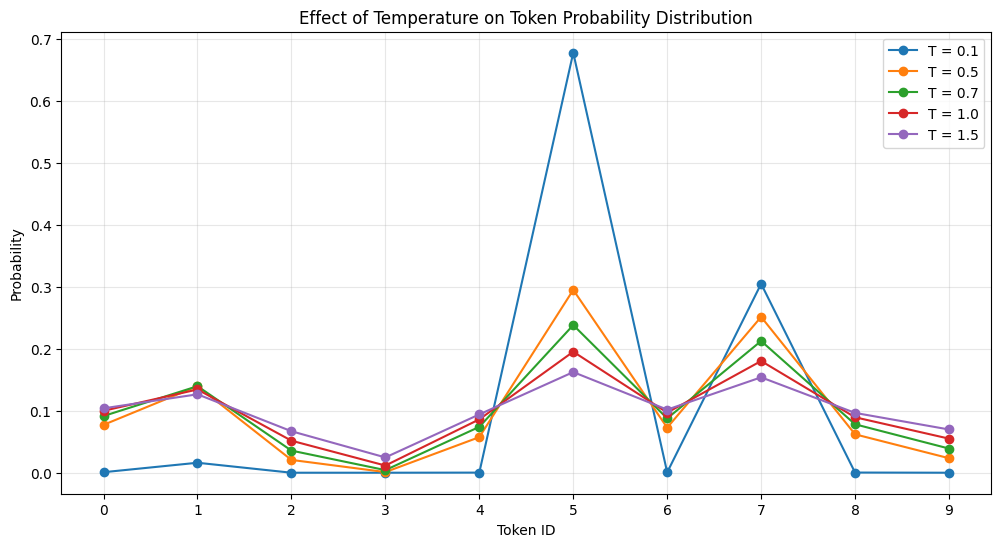

In [ ]:
# Visualize how temperature changes the probability distribution.

import matplotlib.pyplot as plt

temperatures = [0.1, 0.5, 0.7, 1.0, 1.5]

plt.figure(figsize=(12, 6))

for temperature in temperatures:
    adjusted_logits = vocabulary_scores / temperature

    temperature_probabilities = torch.softmax(adjusted_logits, dim=-1)

    plt.plot(
        range(len(temperature_probabilities)),
        temperature_probabilities.detach().numpy(),
        marker="o",
        label=f"T = {temperature}",
    )

plt.xlabel("Token ID")
plt.ylabel("Probability")
plt.title("Effect of Temperature on Token Probability Distribution")
plt.xticks(range(len(vocabulary_scores)))
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

### Result Interpretation

The visualization shows that lower temperatures produce sharper probability peaks, while higher temperatures produce flatter distributions. At $T$ = 0.1, most probability is concentrated on Token ID 5.

### Finding

Temperature controls the concentration of the probability distribution: lower values favor dominant candidates, while higher values increase the relative probability of alternative candidates.

## 11.2 Temperature = 0.1

A very low temperature produces a highly concentrated probability distribution.

At temperature 0.1, the logits are strongly amplified before Softmax, increasing the relative probability of the highest-scoring candidates.

This experiment measures the resulting probability distribution and identifies its highest-probability token.

In [ ]:
# Apply a very low temperature and inspect the resulting distribution.

temperature = 0.1

adjusted_logits = vocabulary_scores / temperature

temperature_probabilities = torch.softmax(adjusted_logits, dim=-1)

highest_token = torch.argmax(temperature_probabilities, dim=-1)

print("Temperature:", temperature)
print("Probabilities:")
print(temperature_probabilities)

print("\nHighest-Probability Token ID:", highest_token.item())

print("Highest Probability:", temperature_probabilities[highest_token].item())

print("Probability Sum:", temperature_probabilities.sum().item())

Temperature: 0.1
Probabilities:
tensor([8.3486e-04, 1.6084e-02, 1.1436e-06, 3.5726e-13, 1.8879e-04, 6.7733e-01,
        6.1609e-04, 3.0467e-01, 2.7698e-04, 2.1295e-06])

Highest-Probability Token ID: 5
Highest Probability: 0.6773290634155273
Probability Sum: 1.0


### Result Interpretation

At temperature 0.1, the probability distribution became highly concentrated. Token ID 5 received 0.677329 probability, while Token ID 7 received 0.304670.

### Finding

A very low temperature strongly concentrates probability on the highest-scoring candidates.

## 11.3 Temperature = 0.5

Temperature 0.5 produces a sharper distribution than the original temperature of 1.0, but less concentrated than temperature 0.1.

The experiment measures the probability distribution, identifies the highest-probability token, and verifies that the probabilities remain normalized.

In [ ]:
# Apply temperature 0.5 and inspect the probability distribution.

temperature = 0.5

adjusted_logits = vocabulary_scores / temperature

temperature_probabilities = torch.softmax(adjusted_logits, dim=-1)

highest_token = torch.argmax(temperature_probabilities, dim=-1)

print("Temperature:", temperature)
print("Probabilities:")
print(temperature_probabilities)

print("\nHighest-Probability Token ID:", highest_token.item())

print("Highest Probability:", temperature_probabilities[highest_token].item())

print("Probability Sum:", temperature_probabilities.sum().item())

Temperature: 0.5
Probabilities:
tensor([0.0772, 0.1395, 0.0207, 0.0010, 0.0574, 0.2949, 0.0727, 0.2513, 0.0619,
        0.0234])

Highest-Probability Token ID: 5
Highest Probability: 0.2948540449142456
Probability Sum: 1.0


### Result Interpretation

At temperature 0.5, Token ID 5 remained the highest-probability candidate with a probability of 0.294854. The probability distribution remained normalized with a total of 1.0.

### Finding

Temperature 0.5 produces a concentrated distribution while allowing more probability mass for alternative candidates than temperature 0.1.

## 11.4 Temperature = 0.7

Temperature 0.7 produces a moderately concentrated probability distribution.

It should be less sharp than temperature 0.5 and more concentrated than temperature 1.0.

The experiment measures the resulting probabilities, identifies the highest-probability token, and verifies probability normalization.

In [ ]:
# Apply temperature 0.7 and inspect the probability distribution.

temperature = 0.7

adjusted_logits = vocabulary_scores / temperature

temperature_probabilities = torch.softmax(adjusted_logits, dim=-1)

highest_token = torch.argmax(temperature_probabilities, dim=-1)

print("Temperature:", temperature)
print("Probabilities:")
print(temperature_probabilities)

print("\nHighest-Probability Token ID:", highest_token.item())

print("Highest Probability:", temperature_probabilities[highest_token].item())

print("Probability Sum:", temperature_probabilities.sum().item())

Temperature: 0.7
Probabilities:
tensor([0.0915, 0.1395, 0.0357, 0.0042, 0.0740, 0.2381, 0.0876, 0.2124, 0.0781,
        0.0390])

Highest-Probability Token ID: 5
Highest Probability: 0.2381143569946289
Probability Sum: 0.9999998807907104


### Result Interpretation

At temperature 0.7, Token ID 5 remained the highest-probability candidate with a probability of 0.238114. The probability sum was 0.99999988, which is effectively 1 due to floating-point precision.

### Finding

Increasing temperature from 0.5 to 0.7 reduced the concentration of probability on the highest-scoring candidate.

## 11.5 Temperature = 1.0

Temperature 1.0 is the baseline configuration.

Dividing logits by 1.0 leaves their values unchanged, so the resulting Softmax distribution is the original probability distribution.

This provides the reference point for comparing lower and higher temperatures.

In [ ]:
# Apply temperature 1.0 as the baseline configuration.

temperature = 1.0

adjusted_logits = vocabulary_scores / temperature

temperature_probabilities = torch.softmax(adjusted_logits, dim=-1)

highest_token = torch.argmax(temperature_probabilities, dim=-1)

print("Temperature:", temperature)
print("Probabilities:")
print(temperature_probabilities)

print("\nHighest-Probability Token ID:", highest_token.item())

print("Highest Probability:", temperature_probabilities[highest_token].item())

print("Probability Sum:", temperature_probabilities.sum().item())

Temperature: 1.0
Probabilities:
tensor([0.0999, 0.1343, 0.0517, 0.0115, 0.0861, 0.1951, 0.0969, 0.1802, 0.0894,
        0.0550])

Highest-Probability Token ID: 5
Highest Probability: 0.19514629244804382
Probability Sum: 1.0


### Result Interpretation

At temperature 1.0, the original probability distribution was preserved. Token ID 5 remained the highest-probability candidate with a probability of 0.195146, and the probability sum was 1.0.

### Finding

Temperature 1.0 provides the baseline distribution against which lower and higher temperature configurations can be compared.

## 11.6 Temperature = 1.5

Temperature 1.5 produces a flatter probability distribution than the baseline temperature of 1.0.

The logits are divided by a value greater than 1 before Softmax, reducing the relative differences between candidate scores.

The experiment measures the resulting probabilities, identifies the highest-probability token, and verifies probability normalization.

In [ ]:
# Apply temperature 1.5 and inspect the probability distribution.

temperature = 1.5

adjusted_logits = vocabulary_scores / temperature

temperature_probabilities = torch.softmax(adjusted_logits, dim=-1)

highest_token = torch.argmax(temperature_probabilities, dim=-1)

print("Temperature:", temperature)
print("Probabilities:")
print(temperature_probabilities)

print("\nHighest-Probability Token ID:", highest_token.item())

print("Highest Probability:", temperature_probabilities[highest_token].item())

print("Probability Sum:", temperature_probabilities.sum().item())

Temperature: 1.5
Probabilities:
tensor([0.1038, 0.1265, 0.0669, 0.0246, 0.0940, 0.1623, 0.1018, 0.1539, 0.0965,
        0.0697])

Highest-Probability Token ID: 5
Highest Probability: 0.16228637099266052
Probability Sum: 1.0000001192092896


### Result Interpretation

At temperature 1.5, Token ID 5 remained the highest-probability candidate with a probability of 0.162286. The probability sum was 1.00000012, which is effectively 1 due to floating-point precision.

### Finding

Higher temperature reduces the concentration of probability on the highest-scoring candidates and produces a flatter distribution.

## 11.7 Compare Results

The temperature experiments can be compared by tracking the highest probability in each distribution.

A decreasing maximum probability as temperature increases indicates that probability mass is becoming more distributed across alternative candidates.

The highest-probability token can also be tracked to verify whether the ranking changes across the tested temperatures.

In [ ]:
# Compare the highest probability across all tested temperatures.

temperature_results = []

for temperature in [0.1, 0.5, 0.7, 1.0, 1.5]:
    adjusted_logits = vocabulary_scores / temperature

    temperature_probabilities = torch.softmax(adjusted_logits, dim=-1)

    highest_token = torch.argmax(temperature_probabilities, dim=-1)

    highest_probability = temperature_probabilities[highest_token].item()

    temperature_results.append(
        {
            "Temperature": temperature,
            "Highest Token ID": highest_token.item(),
            "Highest Probability": highest_probability,
            "Probability Sum": temperature_probabilities.sum().item(),
        }
    )

print("Temperature Comparison")
print("-" * 75)

for result in temperature_results:
    print(
        f"T = {result['Temperature']:<3} | "
        f"Token ID = {result['Highest Token ID']:<2} | "
        f"Highest Probability = {result['Highest Probability']:.6f} | "
        f"Sum = {result['Probability Sum']:.6f}"
    )

Temperature Comparison
---------------------------------------------------------------------------
T = 0.1 | Token ID = 5  | Highest Probability = 0.677329 | Sum = 1.000000
T = 0.5 | Token ID = 5  | Highest Probability = 0.294854 | Sum = 1.000000
T = 0.7 | Token ID = 5  | Highest Probability = 0.238114 | Sum = 1.000000
T = 1.0 | Token ID = 5  | Highest Probability = 0.195146 | Sum = 1.000000
T = 1.5 | Token ID = 5  | Highest Probability = 0.162286 | Sum = 1.000000


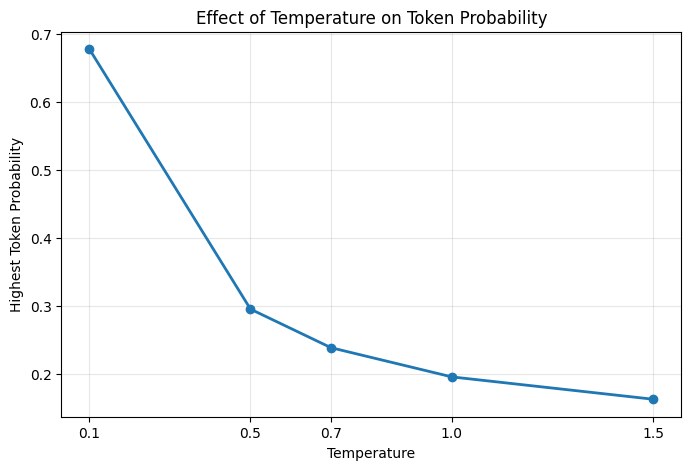

In [ ]:
import matplotlib.pyplot as plt

temperatures = [0.1, 0.5, 0.7, 1.0, 1.5]
highest_probabilities = [0.677329, 0.294854, 0.238114, 0.195146, 0.162286]

plt.figure(figsize=(8, 5))

plt.plot(temperatures, highest_probabilities, marker="o", linewidth=2)

plt.xlabel("Temperature")
plt.ylabel("Highest Token Probability")
plt.title("Effect of Temperature on Token Probability")
plt.xticks(temperatures)
plt.grid(True, alpha=0.3)

plt.show()

### Result Interpretation

| Temperature | Highest Token ID | Highest Probability | Probability Sum |
|---:|---:|---:|---:|
| 0.1 | 5 | 0.677329 | 1.000000 |
| 0.5 | 5 | 0.294854 | 1.000000 |
| 0.7 | 5 | 0.238114 | 1.000000 |
| 1.0 | 5 | 0.195146 | 1.000000 |
| 1.5 | 5 | 0.162286 | 1.000000 |

The highest-probability token remained Token ID 5 across all tested temperatures. Its probability decreased consistently as temperature increased, while every distribution remained normalized.

### Finding

Lower temperature concentrates probability on the highest-scoring token, while higher temperature distributes probability more evenly across alternative tokens.

# 12. Top-k Sampling
## 12.1 Top-k Sampling

Top-k sampling limits the candidate set to the `k` tokens with the highest logits.

The decoding process is:

```text
Full Vocabulary
      ↓
Rank Candidates
      ↓
Keep Top-k
      ↓
Renormalize Probabilities
      ↓
Sample
```

The value of `k` controls how many high-scoring candidates remain available for sampling.

- `k = 1`: Keep only the highest-ranked token and effectively behave like greedy selection.
- `k = 5`: Keep the five highest-ranked candidates.
- Larger values allow more candidates to participate in sampling.

In this experiment, synthetic logits are used to study the Top-k mechanism because real Qwen3.8-27B logits are not available through the Ollama API.

The experiment will compare:

| Top-k | Candidate Set |
|---:|---|
| 1 | Highest-scoring token only |
| 5 | Top 5 tokens |
| 20 | Top 20 tokens |
| 50 | Top 50 tokens |
| 100 | Top 100 tokens |

In [37]:
# Create a larger synthetic vocabulary for Top-k experiments.
torch.manual_seed(42)

synthetic_vocab_size = 1000
synthetic_logits = torch.randn(synthetic_vocab_size)

# Convert logits into a probability distribution.
synthetic_probabilities = torch.softmax(synthetic_logits, dim=-1)

In [ ]:
# Inspect the highest-scoring candidates in the synthetic vocabulary.
# These logits will be used for the upcoming Top-k experiments.

sorted_values, sorted_indices = torch.sort(synthetic_logits, descending=True)

print("Synthetic Vocabulary Size:", synthetic_vocab_size)
print("\nTop 10 Candidate Tokens:")

for rank in range(10):
    token_id = sorted_indices[rank].item()
    logit = sorted_values[rank].item()
    probability = synthetic_probabilities[token_id].item()

    print(
        f"Rank {rank + 1:2d} | "
        f"Token ID = {token_id:3d} | "
        f"Logit = {logit:.6f} | "
        f"Probability = {probability:.6f}"
    )

Synthetic Vocabulary Size: 1000

Top 10 Candidate Tokens:
Rank  1 | Token ID = 701 | Logit = 3.025048 | Probability = 0.012525
Rank  2 | Token ID = 759 | Logit = 2.854381 | Probability = 0.010559
Rank  3 | Token ID = 476 | Logit = 2.833968 | Probability = 0.010346
Rank  4 | Token ID = 691 | Logit = 2.731231 | Probability = 0.009336
Rank  5 | Token ID = 561 | Logit = 2.622147 | Probability = 0.008371
Rank  6 | Token ID = 922 | Logit = 2.602391 | Probability = 0.008207
Rank  7 | Token ID = 609 | Logit = 2.325906 | Probability = 0.006225
Rank  8 | Token ID =  66 | Logit = 2.218076 | Probability = 0.005589
Rank  9 | Token ID = 973 | Logit = 2.186076 | Probability = 0.005413
Rank 10 | Token ID = 583 | Logit = 2.184829 | Probability = 0.005406


## 12.2 Top-k = 1

With `top_k = 1`, only the highest-scoring token is retained.

All other candidates are removed from the candidate set.

After renormalization, the remaining token receives probability `1.0`.

Therefore, `top_k = 1` effectively produces deterministic greedy selection.

In [ ]:
# Keep only the highest-scoring token.
top_k = 1

top_k_values, top_k_indices = torch.topk(synthetic_logits, k=top_k)

# Renormalize the retained logits into probabilities.
top_k_probabilities = torch.softmax(top_k_values, dim=-1)

selected_token_id = top_k_indices[0].item()
selected_probability = top_k_probabilities[0].item()

print("Top-k:", top_k)
print("Selected Token ID:", selected_token_id)
print("Original Logit:", top_k_values[0].item())
print("Renormalized Probability:", selected_probability)
print("Candidate Count:", len(top_k_indices))

Top-k: 1
Selected Token ID: 701
Original Logit: 3.0250484943389893
Renormalized Probability: 1.0
Candidate Count: 1


### Result Interpretation

| Top-k | Candidate Count | Selected Token ID | Original Logit | Renormalized Probability |
|---:|---:|---:|---:|---:|
| 1 | 1 | 701 | 3.025048 | 1.000000 |

Only the highest-scoring candidate was retained. After renormalization, its probability became 1.0.

### Finding

Top-k = 1 keeps only the highest-scoring token, making the selection deterministic and effectively equivalent to greedy decoding.

## 12.3 Top-k = 5

With `top_k = 5`, only the five highest-scoring tokens are retained.

The remaining 995 candidates are removed from the sampling set.

The retained logits are converted into probabilities and renormalized so that the five probabilities sum to 1.

This allows stochastic sampling among the five strongest candidates instead of selecting from the full vocabulary.

In [ ]:
# Keep the five highest-scoring candidates.
top_k = 5

top_k_values, top_k_indices = torch.topk(synthetic_logits, k=top_k)

# Renormalize probabilities across the retained candidates only.
top_k_probabilities = torch.softmax(top_k_values, dim=-1)

print("Top-k:", top_k)
print("Candidate Count:", len(top_k_indices))
print("\nTop-k Candidates:")

for rank in range(top_k):
    token_id = top_k_indices[rank].item()
    logit = top_k_values[rank].item()
    probability = top_k_probabilities[rank].item()

    print(
        f"Rank {rank + 1} | "
        f"Token ID = {token_id} | "
        f"Logit = {logit:.6f} | "
        f"Probability = {probability:.6f}"
    )

print("\nProbability Sum:", top_k_probabilities.sum().item())

Top-k: 5
Candidate Count: 5

Top-k Candidates:
Rank 1 | Token ID = 701 | Logit = 3.025048 | Probability = 0.244920
Rank 2 | Token ID = 759 | Logit = 2.854381 | Probability = 0.206493
Rank 3 | Token ID = 476 | Logit = 2.833968 | Probability = 0.202321
Rank 4 | Token ID = 691 | Logit = 2.731231 | Probability = 0.182567
Rank 5 | Token ID = 561 | Logit = 2.622147 | Probability = 0.163699

Probability Sum: 1.0000001192092896


### Result Interpretation

| Rank | Token ID | Logit | Renormalized Probability |
|---:|---:|---:|---:|
| 1 | 701 | 3.025048 | 0.244920 |
| 2 | 759 | 2.854381 | 0.206493 |
| 3 | 476 | 2.833968 | 0.202321 |
| 4 | 691 | 2.731231 | 0.182567 |
| 5 | 561 | 2.622147 | 0.163699 |

The five highest-scoring candidates were retained, and their probabilities were renormalized to approximately 1.0.

### Finding

Top-k = 5 allows sampling among five high-scoring candidates instead of selecting only the single highest-scoring token.

## 12.4 Top-k = 20

With `top_k = 20`, the twenty highest-scoring candidates are retained.

The remaining 980 candidates are removed, and the retained logits are converted into a normalized probability distribution.

Compared with `top_k = 5`, the candidate set is larger, allowing more tokens to participate in sampling.

In [ ]:
# Keep the twenty highest-scoring candidates.
top_k = 20

top_k_values, top_k_indices = torch.topk(synthetic_logits, k=top_k)

# Renormalize probabilities across the retained candidates only.
top_k_probabilities = torch.softmax(top_k_values, dim=-1)

print("Top-k:", top_k)
print("Candidate Count:", len(top_k_indices))

print("\nTop-k Candidates:")

for rank in range(top_k):
    token_id = top_k_indices[rank].item()
    logit = top_k_values[rank].item()
    probability = top_k_probabilities[rank].item()

    print(
        f"Rank {rank + 1:2d} | "
        f"Token ID = {token_id:3d} | "
        f"Logit = {logit:.6f} | "
        f"Probability = {probability:.6f}"
    )

print("\nProbability Sum:", top_k_probabilities.sum().item())

Top-k: 20
Candidate Count: 20

Top-k Candidates:
Rank  1 | Token ID = 701 | Logit = 3.025048 | Probability = 0.095629
Rank  2 | Token ID = 759 | Logit = 2.854381 | Probability = 0.080625
Rank  3 | Token ID = 476 | Logit = 2.833968 | Probability = 0.078996
Rank  4 | Token ID = 691 | Logit = 2.731231 | Probability = 0.071283
Rank  5 | Token ID = 561 | Logit = 2.622147 | Probability = 0.063916
Rank  6 | Token ID = 922 | Logit = 2.602391 | Probability = 0.062666
Rank  7 | Token ID = 609 | Logit = 2.325906 | Probability = 0.047529
Rank  8 | Token ID =  66 | Logit = 2.218076 | Probability = 0.042670
Rank  9 | Token ID = 973 | Logit = 2.186076 | Probability = 0.041326
Rank 10 | Token ID = 583 | Logit = 2.184829 | Probability = 0.041275
Rank 11 | Token ID = 829 | Logit = 2.147725 | Probability = 0.039772
Rank 12 | Token ID = 370 | Logit = 2.144168 | Probability = 0.039630
Rank 13 | Token ID = 672 | Logit = 2.129625 | Probability = 0.039058
Rank 14 | Token ID =  45 | Logit = 2.122785 | Probabil

### Result Interpretation

| Rank | Token ID | Logit | Renormalized Probability |
|---:|---:|---:|---:|
| 1 | 701 | 3.025048 | 0.095629 |
| 2 | 759 | 2.854381 | 0.080625 |
| 3 | 476 | 2.833968 | 0.078996 |
| 4 | 691 | 2.731231 | 0.071283 |
| 5 | 561 | 2.622147 | 0.063916 |
| 6 | 922 | 2.602391 | 0.062666 |
| 7 | 609 | 2.325906 | 0.047529 |
| 8 | 66 | 2.218076 | 0.042670 |
| 9 | 973 | 2.186076 | 0.041326 |
| 10 | 583 | 2.184829 | 0.041275 |

The top 20 candidates were retained, and their probabilities were renormalized to sum to 1.0.

### Finding

Increasing `top_k` expands the candidate set and distributes probability across more high-scoring tokens.

## 12.5 Top-k = 50

With `top_k = 50`, the fifty highest-scoring candidates are retained.

The remaining 950 candidates are excluded from sampling, and the retained logits are renormalized into a probability distribution.

Compared with smaller `top_k` values, a larger candidate set allows more tokens to participate in sampling.

In [ ]:
# Keep the fifty highest-scoring candidates.
top_k = 50

top_k_values, top_k_indices = torch.topk(synthetic_logits, k=top_k)

# Renormalize probabilities across the retained candidates only.
top_k_probabilities = torch.softmax(top_k_values, dim=-1)

print("Top-k:", top_k)
print("Candidate Count:", len(top_k_indices))

print("\nTop-k Candidates:")

for rank in range(top_k):
    token_id = top_k_indices[rank].item()
    logit = top_k_values[rank].item()
    probability = top_k_probabilities[rank].item()

    print(
        f"Rank {rank + 1:2d} | "
        f"Token ID = {token_id:3d} | "
        f"Logit = {logit:.6f} | "
        f"Probability = {probability:.6f}"
    )

print("\nProbability Sum:", top_k_probabilities.sum().item())

Top-k: 50
Candidate Count: 50

Top-k Candidates:
Rank  1 | Token ID = 701 | Logit = 3.025048 | Probability = 0.050730
Rank  2 | Token ID = 759 | Logit = 2.854381 | Probability = 0.042771
Rank  3 | Token ID = 476 | Logit = 2.833968 | Probability = 0.041907
Rank  4 | Token ID = 691 | Logit = 2.731231 | Probability = 0.037815
Rank  5 | Token ID = 561 | Logit = 2.622147 | Probability = 0.033907
Rank  6 | Token ID = 922 | Logit = 2.602391 | Probability = 0.033244
Rank  7 | Token ID = 609 | Logit = 2.325906 | Probability = 0.025214
Rank  8 | Token ID =  66 | Logit = 2.218076 | Probability = 0.022636
Rank  9 | Token ID = 973 | Logit = 2.186076 | Probability = 0.021923
Rank 10 | Token ID = 583 | Logit = 2.184829 | Probability = 0.021896
Rank 11 | Token ID = 829 | Logit = 2.147725 | Probability = 0.021099
Rank 12 | Token ID = 370 | Logit = 2.144168 | Probability = 0.021024
Rank 13 | Token ID = 672 | Logit = 2.129625 | Probability = 0.020720
Rank 14 | Token ID =  45 | Logit = 2.122785 | Probabil

### Result Interpretation

| Rank | Token ID | Logit | Renormalized Probability |
|---:|---:|---:|---:|
| 1 | 701 | 3.025048 | 0.050730 |
| 2 | 759 | 2.854381 | 0.042771 |
| 3 | 476 | 2.833968 | 0.041907 |
| 4 | 691 | 2.731231 | 0.037815 |
| 5 | 561 | 2.622147 | 0.033907 |
| 6 | 922 | 2.602391 | 0.033244 |
| 7 | 609 | 2.325906 | 0.025214 |
| 8 | 66 | 2.218076 | 0.022636 |
| 9 | 973 | 2.186076 | 0.021923 |
| 10 | 583 | 2.184829 | 0.021896 |

The top 50 candidates were retained, and their probabilities were renormalized to approximately 1.0.

### Finding

Increasing `top_k` expands the candidate set and distributes probability across more high-scoring tokens.

## 12.6 Top-k = 100

With `top_k = 100`, the 100 highest-scoring candidates are retained.

The remaining 900 candidates are excluded, and the retained logits are renormalized into a probability distribution.

This provides a substantially larger candidate set than the previous Top-k configurations.

In [ ]:
# Keep the one hundred highest-scoring candidates.
top_k = 100

top_k_values, top_k_indices = torch.topk(synthetic_logits, k=top_k)

# Renormalize probabilities across the retained candidates only.
top_k_probabilities = torch.softmax(top_k_values, dim=-1)

print("Top-k:", top_k)
print("Candidate Count:", len(top_k_indices))

print("\nTop-k Candidates:")

for rank in range(top_k):
    token_id = top_k_indices[rank].item()
    logit = top_k_values[rank].item()
    probability = top_k_probabilities[rank].item()

    print(
        f"Rank {rank + 1:3d} | "
        f"Token ID = {token_id:3d} | "
        f"Logit = {logit:.6f} | "
        f"Probability = {probability:.6f}"
    )

print("\nProbability Sum:", top_k_probabilities.sum().item())

Top-k: 100
Candidate Count: 100

Top-k Candidates:
Rank   1 | Token ID = 701 | Logit = 3.025048 | Probability = 0.032746
Rank   2 | Token ID = 759 | Logit = 2.854381 | Probability = 0.027608
Rank   3 | Token ID = 476 | Logit = 2.833968 | Probability = 0.027050
Rank   4 | Token ID = 691 | Logit = 2.731231 | Probability = 0.024409
Rank   5 | Token ID = 561 | Logit = 2.622147 | Probability = 0.021887
Rank   6 | Token ID = 922 | Logit = 2.602391 | Probability = 0.021458
Rank   7 | Token ID = 609 | Logit = 2.325906 | Probability = 0.016275
Rank   8 | Token ID =  66 | Logit = 2.218076 | Probability = 0.014611
Rank   9 | Token ID = 973 | Logit = 2.186076 | Probability = 0.014151
Rank  10 | Token ID = 583 | Logit = 2.184829 | Probability = 0.014134
Rank  11 | Token ID = 829 | Logit = 2.147725 | Probability = 0.013619
Rank  12 | Token ID = 370 | Logit = 2.144168 | Probability = 0.013570
Rank  13 | Token ID = 672 | Logit = 2.129625 | Probability = 0.013375
Rank  14 | Token ID =  45 | Logit = 2.1

### Result Interpretation

| Rank | Token ID | Logit | Renormalized Probability |
|---:|---:|---:|---:|
| 1 | 701 | 3.025048 | 0.032746 |
| 2 | 759 | 2.854381 | 0.027608 |
| 3 | 476 | 2.833968 | 0.027050 |
| 4 | 691 | 2.731231 | 0.024409 |
| 5 | 561 | 2.622147 | 0.021887 |
| 6 | 922 | 2.602391 | 0.021458 |
| 7 | 609 | 2.325906 | 0.016275 |
| 8 | 66 | 2.218076 | 0.014611 |
| 9 | 973 | 2.186076 | 0.014151 |
| 10 | 583 | 2.184829 | 0.014134 |

The top 100 candidates were retained, and their probabilities were renormalized to approximately 1.0.

### Finding

Increasing `top_k` expands the candidate set and reduces the probability concentration on the highest-scoring candidate.

## 12.7 Compare Results

The Top-k experiments show how increasing the candidate set changes the probability distribution while keeping the underlying logits fixed.

The main comparison focuses on the number of retained candidates and the probability assigned to the highest-scoring token.

In [ ]:
# Compare the highest-token probability across all Top-k experiments.
# The logits remain fixed while only the candidate set size changes.

top_k_values_list = [1, 5, 20, 50, 100]

highest_probabilities = [1.000000, 0.244920, 0.095629, 0.050730, 0.032746]

comparison = []

for k, probability in zip(top_k_values_list, highest_probabilities):
    comparison.append(
        {
            "Top-k": k,
            "Candidate Count": k,
            "Highest Token ID": 701,
            "Highest Probability": probability,
        }
    )

print("Top-k Comparison")
print("-" * 70)

for row in comparison:
    print(
        f"Top-k = {row['Top-k']:3d} | "
        f"Candidates = {row['Candidate Count']:3d} | "
        f"Highest Token ID = {row['Highest Token ID']:3d} | "
        f"Highest Probability = {row['Highest Probability']:.6f}"
    )

Top-k Comparison
----------------------------------------------------------------------
Top-k =   1 | Candidates =   1 | Highest Token ID = 701 | Highest Probability = 1.000000
Top-k =   5 | Candidates =   5 | Highest Token ID = 701 | Highest Probability = 0.244920
Top-k =  20 | Candidates =  20 | Highest Token ID = 701 | Highest Probability = 0.095629
Top-k =  50 | Candidates =  50 | Highest Token ID = 701 | Highest Probability = 0.050730
Top-k = 100 | Candidates = 100 | Highest Token ID = 701 | Highest Probability = 0.032746


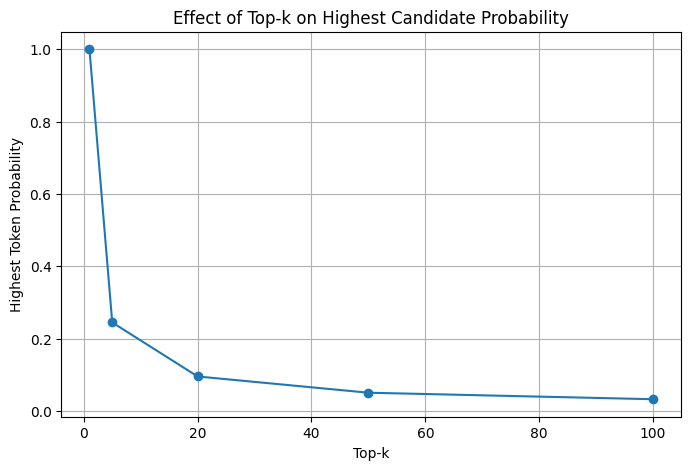

In [ ]:
import matplotlib.pyplot as plt

top_k_values = [1, 5, 20, 50, 100]
highest_probabilities = [1.000000, 0.244920, 0.095629, 0.050730, 0.032746]

plt.figure(figsize=(8, 5))

plt.plot(top_k_values, highest_probabilities, marker="o")

plt.xlabel("Top-k")
plt.ylabel("Highest Token Probability")
plt.title("Effect of Top-k on Highest Candidate Probability")
plt.grid(True)

plt.show()

### Result Interpretation

| Top-k | Candidate Count | Highest Token ID | Highest Probability |
|---:|---:|---:|---:|
| 1 | 1 | 701 | 1.000000 |
| 5 | 5 | 701 | 0.244920 |
| 20 | 20 | 701 | 0.095629 |
| 50 | 50 | 701 | 0.050730 |
| 100 | 100 | 701 | 0.032746 |

The highest-scoring token remains the same because the logits are fixed. Increasing Top-k expands the candidate set, so the probability mass is redistributed across more tokens.

### Finding

Larger Top-k values increase sampling diversity by allowing more candidate tokens. Top-k = 1 is equivalent to selecting the highest-scoring token.

# 13. Top-p Sampling
## 13.1 Top-p Sampling Concept

Top-p sampling, also called nucleus sampling, selects a dynamic set of candidate tokens based on cumulative probability.

The procedure is:

1. Convert logits into probabilities.
2. Sort tokens by probability in descending order.
3. Compute the cumulative probability.
4. Keep the smallest set of tokens whose cumulative probability reaches the Top-p threshold.
5. Renormalize the selected probabilities.
6. Sample from the resulting candidate distribution.

Unlike Top-k, which keeps a fixed number of candidates, Top-p allows the candidate count to change according to the probability distribution.

Conceptually:

Full Vocabulary → Sort by Probability → Cumulative Probability → Top-p Nucleus → Renormalize → Sample

For example, if the cumulative probabilities are:

- Token A: 0.40
- Token B: 0.25
- Token C: 0.15
- Token D: 0.10

Then Top-p = 0.80 keeps A, B, and C because their cumulative probability reaches 0.80.

In [ ]:
import torch

# Recreate the same synthetic distribution used in the Top-k experiments.
torch.manual_seed(42)

synthetic_vocab_size = 1000

synthetic_logits = torch.randn(synthetic_vocab_size)
synthetic_probabilities = torch.softmax(synthetic_logits, dim=-1)

# Sort probabilities from highest to lowest.
sorted_probabilities, sorted_indices = torch.sort(
    synthetic_probabilities, descending=True
)

# Compute cumulative probability.
cumulative_probabilities = torch.cumsum(sorted_probabilities, dim=0)

print("Top-p Mechanics Distribution")
print("-" * 70)

for i in range(10):
    token_id = sorted_indices[i].item()
    probability = sorted_probabilities[i].item()
    cumulative = cumulative_probabilities[i].item()

    print(
        f"Rank = {i + 1:2d} | "
        f"Token ID = {token_id:3d} | "
        f"Probability = {probability:.6f} | "
        f"Cumulative = {cumulative:.6f}"
    )

Top-p Mechanics Distribution
----------------------------------------------------------------------
Rank =  1 | Token ID = 701 | Probability = 0.012525 | Cumulative = 0.012525
Rank =  2 | Token ID = 759 | Probability = 0.010559 | Cumulative = 0.023084
Rank =  3 | Token ID = 476 | Probability = 0.010346 | Cumulative = 0.033430
Rank =  4 | Token ID = 691 | Probability = 0.009336 | Cumulative = 0.042766
Rank =  5 | Token ID = 561 | Probability = 0.008371 | Cumulative = 0.051137
Rank =  6 | Token ID = 922 | Probability = 0.008207 | Cumulative = 0.059344
Rank =  7 | Token ID = 609 | Probability = 0.006225 | Cumulative = 0.065569
Rank =  8 | Token ID =  66 | Probability = 0.005589 | Cumulative = 0.071158
Rank =  9 | Token ID = 973 | Probability = 0.005413 | Cumulative = 0.076570
Rank = 10 | Token ID = 583 | Probability = 0.005406 | Cumulative = 0.081976


### Result Interpretation

| Rank | Token ID | Probability | Cumulative Probability |
|---:|---:|---:|---:|
| 1 | 701 | 0.012525 | 0.012525 |
| 2 | 759 | 0.010559 | 0.023084 |
| 3 | 476 | 0.010346 | 0.033430 |
| 4 | 691 | 0.009336 | 0.042766 |
| 5 | 561 | 0.008371 | 0.051137 |
| 6 | 922 | 0.008207 | 0.059344 |
| 7 | 609 | 0.006225 | 0.065569 |
| 8 | 66 | 0.005589 | 0.071158 |
| 9 | 973 | 0.005413 | 0.076570 |
| 10 | 583 | 0.005406 | 0.081976 |

The probability distribution is relatively spread across the vocabulary. The top 10 candidates account for only 8.1976% of the total probability mass.

### Finding

Top-p selects candidates according to cumulative probability rather than a fixed candidate count. The required candidate count therefore depends on the shape of the probability distribution.

## 13.2 Top-p = 0.7

Top-p = 0.7 keeps the smallest set of highest-probability tokens whose cumulative probability reaches the 0.70 threshold.

The candidate set is determined dynamically from the probability distribution.

After filtering, the selected probabilities are renormalized so that their sum becomes approximately 1.0.

This experiment uses the fixed synthetic probability distribution from the Top-p mechanics experiment.

In [ ]:
# Apply Top-p filtering with p = 0.7.
# The probability distribution remains fixed; only the Top-p threshold changes.

top_p = 0.7

# Find the smallest candidate set whose cumulative probability reaches Top-p.
cutoff_index = torch.searchsorted(cumulative_probabilities, torch.tensor(top_p)).item()

# Include the token that reaches the threshold.
candidate_count = cutoff_index + 1

selected_probabilities = sorted_probabilities[:candidate_count]
selected_indices = sorted_indices[:candidate_count]

# Renormalize probabilities inside the Top-p nucleus.
renormalized_probabilities = selected_probabilities / selected_probabilities.sum()

print(f"Top-p = {top_p}")
print("-" * 70)
print(f"Candidate Count = {candidate_count}")
print(f"Original Probability Mass = {selected_probabilities.sum().item():.6f}")
print(f"Renormalized Probability Sum = {renormalized_probabilities.sum().item():.6f}")
print()

print("First 10 Top-p Candidates")
print("-" * 70)

for i in range(min(10, candidate_count)):
    token_id = selected_indices[i].item()
    original_probability = selected_probabilities[i].item()
    renormalized_probability = renormalized_probabilities[i].item()

    print(
        f"Rank = {i + 1:2d} | "
        f"Token ID = {token_id:3d} | "
        f"Original P = {original_probability:.6f} | "
        f"Renormalized P = {renormalized_probability:.6f}"
    )

Top-p = 0.7
----------------------------------------------------------------------
Candidate Count = 319
Original Probability Mass = 0.700075
Renormalized Probability Sum = 1.000000

First 10 Top-p Candidates
----------------------------------------------------------------------
Rank =  1 | Token ID = 701 | Original P = 0.012525 | Renormalized P = 0.017890
Rank =  2 | Token ID = 759 | Original P = 0.010559 | Renormalized P = 0.015083
Rank =  3 | Token ID = 476 | Original P = 0.010346 | Renormalized P = 0.014779
Rank =  4 | Token ID = 691 | Original P = 0.009336 | Renormalized P = 0.013336
Rank =  5 | Token ID = 561 | Original P = 0.008371 | Renormalized P = 0.011957
Rank =  6 | Token ID = 922 | Original P = 0.008207 | Renormalized P = 0.011724
Rank =  7 | Token ID = 609 | Original P = 0.006225 | Renormalized P = 0.008892
Rank =  8 | Token ID =  66 | Original P = 0.005589 | Renormalized P = 0.007983
Rank =  9 | Token ID = 973 | Original P = 0.005413 | Renormalized P = 0.007731
Rank = 10

### Result Interpretation

| Metric | Value |
|---|---:|
| Top-p | 0.70 |
| Candidate Count | 319 |
| Original Probability Mass | 0.700075 |
| Renormalized Probability Sum | 1.000000 |
| Highest Token ID | 701 |
| Highest Renormalized Probability | 0.017890 |

The Top-p nucleus contains 319 candidates because the probability distribution is relatively spread out. The selected probability mass slightly exceeds 0.70 because the first token crossing the threshold must be included.

After filtering, the probabilities are renormalized to sum to 1.0.

### Finding

Top-p dynamically determines the candidate count from cumulative probability. For this distribution, Top-p = 0.7 retains 319 candidates rather than a fixed number.

## 13.3 Top-p = 0.9

Top-p = 0.9 keeps the smallest set of highest-probability tokens whose cumulative probability reaches the 0.90 threshold.

The candidate count is expected to be larger than Top-p = 0.7 because more probability mass must be retained.

After filtering, the selected probabilities are renormalized to sum to approximately 1.0.

In [ ]:
# Apply Top-p filtering with p = 0.9.
# The probability distribution remains fixed so the comparison with Top-p = 0.7 is controlled.

top_p = 0.9

# Find the smallest candidate set whose cumulative probability reaches Top-p.
cutoff_index = torch.searchsorted(cumulative_probabilities, torch.tensor(top_p)).item()

# Include the token that reaches the threshold.
candidate_count = cutoff_index + 1

selected_probabilities = sorted_probabilities[:candidate_count]
selected_indices = sorted_indices[:candidate_count]

# Renormalize probabilities inside the Top-p nucleus.
renormalized_probabilities = selected_probabilities / selected_probabilities.sum()

print(f"Top-p = {top_p}")
print("-" * 70)
print(f"Candidate Count = {candidate_count}")
print(f"Original Probability Mass = {selected_probabilities.sum().item():.6f}")
print(f"Renormalized Probability Sum = {renormalized_probabilities.sum().item():.6f}")
print()

print("First 10 Top-p Candidates")
print("-" * 70)

for i in range(min(10, candidate_count)):
    token_id = selected_indices[i].item()
    original_probability = selected_probabilities[i].item()
    renormalized_probability = renormalized_probabilities[i].item()

    print(
        f"Rank = {i + 1:2d} | "
        f"Token ID = {token_id:3d} | "
        f"Original P = {original_probability:.6f} | "
        f"Renormalized P = {renormalized_probability:.6f}"
    )

Top-p = 0.9
----------------------------------------------------------------------
Candidate Count = 611
Original Probability Mass = 0.900011
Renormalized Probability Sum = 1.000000

First 10 Top-p Candidates
----------------------------------------------------------------------
Rank =  1 | Token ID = 701 | Original P = 0.012525 | Renormalized P = 0.013916
Rank =  2 | Token ID = 759 | Original P = 0.010559 | Renormalized P = 0.011733
Rank =  3 | Token ID = 476 | Original P = 0.010346 | Renormalized P = 0.011496
Rank =  4 | Token ID = 691 | Original P = 0.009336 | Renormalized P = 0.010373
Rank =  5 | Token ID = 561 | Original P = 0.008371 | Renormalized P = 0.009301
Rank =  6 | Token ID = 922 | Original P = 0.008207 | Renormalized P = 0.009119
Rank =  7 | Token ID = 609 | Original P = 0.006225 | Renormalized P = 0.006916
Rank =  8 | Token ID =  66 | Original P = 0.005589 | Renormalized P = 0.006209
Rank =  9 | Token ID = 973 | Original P = 0.005413 | Renormalized P = 0.006014
Rank = 10

### Result Interpretation

| Metric | Value |
|---|---:|
| Top-p | 0.90 |
| Candidate Count | 611 |
| Original Probability Mass | 0.900011 |
| Renormalized Probability Sum | 1.000000 |
| Highest Token ID | 701 |
| Highest Renormalized Probability | 0.013916 |

Increasing Top-p from 0.70 to 0.90 substantially increases the candidate set from 319 to 611 tokens.

The selected probability mass slightly exceeds 0.90 because the first token crossing the threshold must be included.

### Finding

Higher Top-p retains more probability mass and therefore allows a larger dynamic candidate set. The number of candidates depends on the probability distribution rather than being fixed.

## 13.4 Top-p = 0.95

Top-p = 0.95 keeps the smallest set of highest-probability tokens whose cumulative probability reaches the 0.95 threshold.

Compared with Top-p = 0.70 and Top-p = 0.90, this setting retains more probability mass and is expected to produce a larger candidate set.

After filtering, the selected probabilities are renormalized so that their sum is approximately 1.0.

In [ ]:
# Apply Top-p filtering with p = 0.95.
# The probability distribution remains fixed for a controlled comparison.

top_p = 0.95

# Find the smallest candidate set whose cumulative probability reaches Top-p.
cutoff_index = torch.searchsorted(cumulative_probabilities, torch.tensor(top_p)).item()

# Include the token that reaches the threshold.
candidate_count = cutoff_index + 1

selected_probabilities = sorted_probabilities[:candidate_count]
selected_indices = sorted_indices[:candidate_count]

# Renormalize probabilities inside the Top-p nucleus.
renormalized_probabilities = selected_probabilities / selected_probabilities.sum()

print(f"Top-p = {top_p}")
print("-" * 70)
print(f"Candidate Count = {candidate_count}")
print(f"Original Probability Mass = {selected_probabilities.sum().item():.6f}")
print(f"Renormalized Probability Sum = {renormalized_probabilities.sum().item():.6f}")
print()

print("First 10 Top-p Candidates")
print("-" * 70)

for i in range(min(10, candidate_count)):
    token_id = selected_indices[i].item()
    original_probability = selected_probabilities[i].item()
    renormalized_probability = renormalized_probabilities[i].item()

    print(
        f"Rank = {i + 1:2d} | "
        f"Token ID = {token_id:3d} | "
        f"Original P = {original_probability:.6f} | "
        f"Renormalized P = {renormalized_probability:.6f}"
    )

Top-p = 0.95
----------------------------------------------------------------------
Candidate Count = 744
Original Probability Mass = 0.950272
Renormalized Probability Sum = 1.000000

First 10 Top-p Candidates
----------------------------------------------------------------------
Rank =  1 | Token ID = 701 | Original P = 0.012525 | Renormalized P = 0.013180
Rank =  2 | Token ID = 759 | Original P = 0.010559 | Renormalized P = 0.011112
Rank =  3 | Token ID = 476 | Original P = 0.010346 | Renormalized P = 0.010887
Rank =  4 | Token ID = 691 | Original P = 0.009336 | Renormalized P = 0.009824
Rank =  5 | Token ID = 561 | Original P = 0.008371 | Renormalized P = 0.008809
Rank =  6 | Token ID = 922 | Original P = 0.008207 | Renormalized P = 0.008637
Rank =  7 | Token ID = 609 | Original P = 0.006225 | Renormalized P = 0.006551
Rank =  8 | Token ID =  66 | Original P = 0.005589 | Renormalized P = 0.005881
Rank =  9 | Token ID = 973 | Original P = 0.005413 | Renormalized P = 0.005696
Rank = 1

### Result Interpretation

| Metric | Value |
|---|---:|
| Top-p | 0.95 |
| Candidate Count | 744 |
| Original Probability Mass | 0.950272 |
| Renormalized Probability Sum | 1.000000 |
| Highest Token ID | 701 |
| Highest Renormalized Probability | 0.013180 |

Increasing Top-p from 0.90 to 0.95 increases the candidate set from 611 to 744 tokens.

The selected probability mass slightly exceeds 0.95 because the first token crossing the threshold must be included.

### Finding

Higher Top-p values retain more probability mass and allow a larger dynamic candidate set. The candidate count is determined by the probability distribution.

## 13.5 Top-p = 1.0

Top-p = 1.0 retains the complete probability distribution.

Because the threshold represents 100% of the probability mass, all tokens are included in the candidate set.

No probability mass is removed, so renormalization should preserve the original distribution with a total probability of approximately 1.0.

In [ ]:
# Apply Top-p filtering with p = 1.0.
# This should retain the complete probability distribution.

top_p = 1.0

# Find the smallest candidate set whose cumulative probability reaches Top-p.
cutoff_index = torch.searchsorted(cumulative_probabilities, torch.tensor(top_p)).item()

# Include the token that reaches the threshold.
candidate_count = cutoff_index + 1

selected_probabilities = sorted_probabilities[:candidate_count]
selected_indices = sorted_indices[:candidate_count]

# Renormalize the selected probabilities.
renormalized_probabilities = selected_probabilities / selected_probabilities.sum()

print(f"Top-p = {top_p}")
print("-" * 70)
print(f"Candidate Count = {candidate_count}")
print(f"Original Probability Mass = {selected_probabilities.sum().item():.6f}")
print(f"Renormalized Probability Sum = {renormalized_probabilities.sum().item():.6f}")
print()

print("First 10 Top-p Candidates")
print("-" * 70)

for i in range(min(10, candidate_count)):
    token_id = selected_indices[i].item()
    original_probability = selected_probabilities[i].item()
    renormalized_probability = renormalized_probabilities[i].item()

    print(
        f"Rank = {i + 1:2d} | "
        f"Token ID = {token_id:3d} | "
        f"Original P = {original_probability:.6f} | "
        f"Renormalized P = {renormalized_probability:.6f}"
    )

Top-p = 1.0
----------------------------------------------------------------------
Candidate Count = 1000
Original Probability Mass = 1.000000
Renormalized Probability Sum = 1.000000

First 10 Top-p Candidates
----------------------------------------------------------------------
Rank =  1 | Token ID = 701 | Original P = 0.012525 | Renormalized P = 0.012525
Rank =  2 | Token ID = 759 | Original P = 0.010559 | Renormalized P = 0.010559
Rank =  3 | Token ID = 476 | Original P = 0.010346 | Renormalized P = 0.010346
Rank =  4 | Token ID = 691 | Original P = 0.009336 | Renormalized P = 0.009336
Rank =  5 | Token ID = 561 | Original P = 0.008371 | Renormalized P = 0.008371
Rank =  6 | Token ID = 922 | Original P = 0.008207 | Renormalized P = 0.008207
Rank =  7 | Token ID = 609 | Original P = 0.006225 | Renormalized P = 0.006225
Rank =  8 | Token ID =  66 | Original P = 0.005589 | Renormalized P = 0.005589
Rank =  9 | Token ID = 973 | Original P = 0.005413 | Renormalized P = 0.005413
Rank = 1

### Result Interpretation

| Metric | Value |
|---|---:|
| Top-p | 1.00 |
| Candidate Count | 1000 |
| Original Probability Mass | 1.000000 |
| Renormalized Probability Sum | 1.000000 |
| Highest Token ID | 701 |
| Highest Probability | 0.012525 |

Top-p = 1.0 retains the complete vocabulary distribution. No probability mass is removed, so renormalization does not change the individual probabilities.

### Finding

Top-p = 1.0 applies no nucleus filtering. All candidates remain available for sampling.

### 13.6 Compare Results

As the Top-p threshold increases, more probability mass is retained and the candidate set becomes larger.

Unlike Top-k, Top-p does not specify a fixed number of candidates. The candidate count is determined dynamically by the probability distribution.

In [ ]:
# Compare all Top-p experiments using the fixed synthetic distribution.

top_p_values = [0.70, 0.90, 0.95, 1.00]
candidate_counts = [319, 611, 744, 1000]
probability_mass = [0.700075, 0.900011, 0.950272, 1.000000]
highest_probabilities = [0.017890, 0.013916, 0.013180, 0.012525]

print("Top-p Comparison")
print("-" * 85)

for p, count, mass, highest_probability in zip(
    top_p_values, candidate_counts, probability_mass, highest_probabilities
):
    print(
        f"Top-p = {p:.2f} | "
        f"Candidates = {count:4d} | "
        f"Probability Mass = {mass:.6f} | "
        f"Highest Probability = {highest_probability:.6f}"
    )

Top-p Comparison
-------------------------------------------------------------------------------------
Top-p = 0.70 | Candidates =  319 | Probability Mass = 0.700075 | Highest Probability = 0.017890
Top-p = 0.90 | Candidates =  611 | Probability Mass = 0.900011 | Highest Probability = 0.013916
Top-p = 0.95 | Candidates =  744 | Probability Mass = 0.950272 | Highest Probability = 0.013180
Top-p = 1.00 | Candidates = 1000 | Probability Mass = 1.000000 | Highest Probability = 0.012525


### Result Interpretation

| Top-p | Candidate Count | Probability Mass | Highest Probability |
|---:|---:|---:|---:|
| 0.70 | 319 | 0.700075 | 0.017890 |
| 0.90 | 611 | 0.900011 | 0.013916 |
| 0.95 | 744 | 0.950272 | 0.013180 |
| 1.00 | 1000 | 1.000000 | 0.012525 |

Increasing Top-p increases the retained probability mass and dynamically expands the candidate set.

### Finding

Top-p controls retained probability mass rather than a fixed candidate count. Higher Top-p values generally allow more candidate tokens and greater sampling diversity.

# 14. Combined Sampling
## 14.1 Temperature + Top-k + Top-p

Combined sampling applies multiple decoding controls to the same probability distribution.

The three parameters serve different purposes:

- Temperature changes the sharpness of the probability distribution.
- Top-k limits the candidate set to the k highest-scoring tokens.
- Top-p limits the candidate set using cumulative probability mass.

Conceptually:

Logits
→ Temperature Scaling
→ Top-k Filtering
→ Top-p Filtering
→ Renormalization
→ Sampling

Combining these parameters provides more control over the balance between deterministic and diverse generation.

In [ ]:
import torch

# Recreate the fixed synthetic logits used throughout the decoding experiments.
torch.manual_seed(42)

synthetic_vocab_size = 1000
synthetic_logits = torch.randn(synthetic_vocab_size)


def combined_sampling_distribution(logits, temperature=1.0, top_k=None, top_p=None):
    """
    Apply temperature scaling, Top-k filtering, and Top-p filtering.
    Returns the final normalized probability distribution.
    """

    # Clone the logits to avoid modifying the original tensor.
    working_logits = logits.clone()

    # Step 1: Temperature scaling.
    if temperature <= 0:
        raise ValueError("Temperature must be greater than 0.")

    working_logits = working_logits / temperature

    # Step 2: Top-k filtering.
    if top_k is not None:
        if top_k < 1 or top_k > working_logits.numel():
            raise ValueError("top_k must be within the vocabulary size.")

        top_k_values, _ = torch.topk(working_logits, top_k)
        kth_value = top_k_values[-1]

        working_logits[working_logits < kth_value] = float("-inf")

    # Convert filtered logits to probabilities.
    probabilities = torch.softmax(working_logits, dim=-1)

    # Step 3: Top-p filtering.
    if top_p is not None:
        if not 0 < top_p <= 1:
            raise ValueError("top_p must be in the range (0, 1].")

        sorted_probabilities, sorted_indices = torch.sort(
            probabilities, descending=True
        )

        cumulative_probabilities = torch.cumsum(sorted_probabilities, dim=-1)

        # Keep tokens until the cumulative probability reaches Top-p.
        cutoff_index = torch.searchsorted(
            cumulative_probabilities, torch.tensor(top_p)
        ).item()

        candidate_count = cutoff_index + 1

        nucleus_indices = sorted_indices[:candidate_count]

        nucleus_mask = torch.zeros_like(probabilities, dtype=torch.bool)
        nucleus_mask[nucleus_indices] = True

        probabilities = torch.where(
            nucleus_mask, probabilities, torch.zeros_like(probabilities)
        )

        # Renormalize after Top-p filtering.
        probabilities = probabilities / probabilities.sum()

    return probabilities


# Example combined configuration.
temperature = 0.7
top_k = 50
top_p = 0.9

final_probabilities = combined_sampling_distribution(
    synthetic_logits, temperature=temperature, top_k=top_k, top_p=top_p
)

# Inspect the final candidate distribution.
candidate_count = (final_probabilities > 0).sum().item()

top_probabilities, top_indices = torch.topk(
    final_probabilities, min(10, candidate_count)
)

print("Combined Sampling Configuration")
print("-" * 70)
print(f"Temperature = {temperature}")
print(f"Top-k = {top_k}")
print(f"Top-p = {top_p}")
print(f"Final Candidate Count = {candidate_count}")
print(f"Probability Sum = {final_probabilities.sum().item():.6f}")
print()

print("Top Candidates")
print("-" * 70)

for rank, (token_id, probability) in enumerate(
    zip(top_indices.tolist(), top_probabilities.tolist()), start=1
):
    print(
        f"Rank = {rank:2d} | Token ID = {token_id:3d} | Probability = {probability:.6f}"
    )

Combined Sampling Configuration
----------------------------------------------------------------------
Temperature = 0.7
Top-k = 50
Top-p = 0.9
Final Candidate Count = 42
Probability Sum = 1.000000

Top Candidates
----------------------------------------------------------------------
Rank =  1 | Token ID = 701 | Probability = 0.079404
Rank =  2 | Token ID = 759 | Probability = 0.062224
Rank =  3 | Token ID = 476 | Probability = 0.060435
Rank =  4 | Token ID = 691 | Probability = 0.052186
Rank =  5 | Token ID = 561 | Probability = 0.044655
Rank =  6 | Token ID = 922 | Probability = 0.043413
Rank =  7 | Token ID = 609 | Probability = 0.029247
Rank =  8 | Token ID =  66 | Probability = 0.025071
Rank =  9 | Token ID = 973 | Probability = 0.023951
Rank = 10 | Token ID = 583 | Probability = 0.023908


### Result Interpretation

| Parameter | Value |
|---|---:|
| Temperature | 0.7 |
| Top-k | 50 |
| Top-p | 0.9 |
| Final Candidate Count | 42 |
| Probability Sum | 1.000000 |
| Highest Token ID | 701 |
| Highest Probability | 0.079404 |

Temperature modifies the probability distribution, Top-k limits the candidate pool, and Top-p further filters the candidates using cumulative probability.

The final distribution contains 42 candidates and is normalized to a probability sum of 1.0.

### Finding

Combined sampling provides layered control over the next-token distribution. Temperature controls probability sharpness, Top-k limits the maximum candidate pool, and Top-p dynamically selects the final nucleus.

## 14.2 Controlled Parameter Experiment

A controlled decoding experiment changes one parameter while keeping the other parameters fixed.

For this experiment:

- Top-k remains fixed at 50.
- Top-p remains fixed at 0.9.
- Temperature is varied across multiple values.

The goal is to isolate the effect of temperature on the final combined sampling distribution.

The results are calculated directly from the fixed synthetic logits rather than being manually entered.

In [ ]:
# Controlled experiment:
# Keep Top-k and Top-p fixed while changing only Temperature.

temperature_values = [0.5, 0.7, 1.0, 1.5]

fixed_top_k = 50
fixed_top_p = 0.9

controlled_results = []

for temperature in temperature_values:
    probabilities = combined_sampling_distribution(
        synthetic_logits, temperature=temperature, top_k=fixed_top_k, top_p=fixed_top_p
    )

    candidate_count = (probabilities > 0).sum().item()

    highest_probability, highest_index = torch.max(probabilities, dim=0)

    controlled_results.append(
        {
            "Temperature": temperature,
            "Top-k": fixed_top_k,
            "Top-p": fixed_top_p,
            "Candidate Count": candidate_count,
            "Highest Token ID": highest_index.item(),
            "Highest Probability": highest_probability.item(),
            "Probability Sum": probabilities.sum().item(),
        }
    )


print("Controlled Temperature Experiment")
print("-" * 105)

for result in controlled_results:
    print(
        f"Temperature = {result['Temperature']:.1f} | "
        f"Top-k = {result['Top-k']:2d} | "
        f"Top-p = {result['Top-p']:.1f} | "
        f"Candidates = {result['Candidate Count']:2d} | "
        f"Highest Token ID = {result['Highest Token ID']:3d} | "
        f"Highest Probability = {result['Highest Probability']:.6f} | "
        f"Sum = {result['Probability Sum']:.6f}"
    )

Controlled Temperature Experiment
---------------------------------------------------------------------------------------------------------
Temperature = 0.5 | Top-k = 50 | Top-p = 0.9 | Candidates = 39 | Highest Token ID = 701 | Highest Probability = 0.121453 | Sum = 1.000000
Temperature = 0.7 | Top-k = 50 | Top-p = 0.9 | Candidates = 42 | Highest Token ID = 701 | Highest Probability = 0.079404 | Sum = 1.000000
Temperature = 1.0 | Top-k = 50 | Top-p = 0.9 | Candidates = 43 | Highest Token ID = 701 | Highest Probability = 0.056051 | Sum = 1.000000
Temperature = 1.5 | Top-k = 50 | Top-p = 0.9 | Candidates = 44 | Highest Token ID = 701 | Highest Probability = 0.041635 | Sum = 1.000000


### Result Interpretation

| Temperature | Top-k | Top-p | Candidates | Highest Token ID | Highest Probability |
|---:|---:|---:|---:|---:|---:|
| 0.5 | 50 | 0.9 | 39 | 701 | 0.121453 |
| 0.7 | 50 | 0.9 | 42 | 701 | 0.079404 |
| 1.0 | 50 | 0.9 | 43 | 701 | 0.056051 |
| 1.5 | 50 | 0.9 | 44 | 701 | 0.041635 |

Increasing temperature spreads probability mass across more candidates and reduces the probability of the highest-scoring token.

The candidate count also changes because Top-p operates on the temperature-adjusted distribution.

### Finding

Temperature controls probability concentration, while Top-k and Top-p constrain the candidate space. Changing temperature can therefore indirectly change the final Top-p candidate count.

## 14.3 Compare Sampling Configurations

Different combinations of Temperature, Top-k, and Top-p produce different final sampling distributions.

This experiment compares several decoding configurations using the same fixed synthetic logits.

For each configuration, the experiment calculates:

- Temperature
- Top-k
- Top-p
- Final candidate count
- Highest-scoring token ID
- Highest token probability
- Probability sum

All values are calculated programmatically to keep the comparison reproducible.

In [ ]:
# Compare multiple combined sampling configurations.
# The synthetic logits remain fixed across all experiments.

sampling_configurations = [
    {"Name": "Conservative", "Temperature": 0.5, "Top-k": 20, "Top-p": 0.8},
    {"Name": "Balanced", "Temperature": 0.7, "Top-k": 50, "Top-p": 0.9},
    {"Name": "Diverse", "Temperature": 1.0, "Top-k": 50, "Top-p": 0.95},
    {"Name": "Broad", "Temperature": 1.5, "Top-k": 100, "Top-p": 1.0},
]

comparison_results = []

for configuration in sampling_configurations:
    probabilities = combined_sampling_distribution(
        synthetic_logits,
        temperature=configuration["Temperature"],
        top_k=configuration["Top-k"],
        top_p=configuration["Top-p"],
    )

    candidate_count = (probabilities > 0).sum().item()

    highest_probability, highest_index = torch.max(probabilities, dim=0)

    comparison_results.append(
        {
            "Name": configuration["Name"],
            "Temperature": configuration["Temperature"],
            "Top-k": configuration["Top-k"],
            "Top-p": configuration["Top-p"],
            "Candidate Count": candidate_count,
            "Highest Token ID": highest_index.item(),
            "Highest Probability": highest_probability.item(),
            "Probability Sum": probabilities.sum().item(),
        }
    )


print("Combined Sampling Configuration Comparison")
print("-" * 125)

for result in comparison_results:
    print(
        f"{result['Name']:12s} | "
        f"T = {result['Temperature']:.1f} | "
        f"Top-k = {result['Top-k']:3d} | "
        f"Top-p = {result['Top-p']:.2f} | "
        f"Candidates = {result['Candidate Count']:3d} | "
        f"Highest ID = {result['Highest Token ID']:3d} | "
        f"Highest P = {result['Highest Probability']:.6f} | "
        f"Sum = {result['Probability Sum']:.6f}"
    )

Combined Sampling Configuration Comparison
-----------------------------------------------------------------------------------------------------------------------------
Conservative | T = 0.5 | Top-k =  20 | Top-p = 0.80 | Candidates =  12 | Highest ID = 701 | Highest P = 0.200446 | Sum = 1.000000
Balanced     | T = 0.7 | Top-k =  50 | Top-p = 0.90 | Candidates =  42 | Highest ID = 701 | Highest P = 0.079404 | Sum = 1.000000
Diverse      | T = 1.0 | Top-k =  50 | Top-p = 0.95 | Candidates =  47 | Highest ID = 701 | Highest P = 0.052844 | Sum = 1.000000
Broad        | T = 1.5 | Top-k = 100 | Top-p = 1.00 | Candidates = 100 | Highest ID = 701 | Highest P = 0.022471 | Sum = 1.000000


### Result Interpretation

| Configuration | Temperature | Top-k | Top-p | Candidates | Highest Probability |
|---|---:|---:|---:|---:|---:|
| Conservative | 0.5 | 20 | 0.80 | 12 | 0.200446 |
| Balanced | 0.7 | 50 | 0.90 | 42 | 0.079404 |
| Diverse | 1.0 | 50 | 0.95 | 47 | 0.052844 |
| Broad | 1.5 | 100 | 1.00 | 100 | 0.022471 |

The configurations demonstrate how Temperature, Top-k, and Top-p interact to control the final candidate distribution.

More restrictive configurations produce fewer candidates and concentrate more probability on the highest-scoring token. Broader configurations retain more candidates and distribute probability more widely.

### Finding

Combined sampling provides layered control over generation diversity. Lower Temperature, smaller Top-k, and lower Top-p produce more concentrated distributions, while broader settings increase the available sampling space.

# 15. Seeded Reproducibility

# 16. Token-Level Generation Trace

# 17. Real Autoregressive Generation

# 18. Manual Generation Loop

# 19. Stop Conditions

# 20. Input Tokens vs Generated Tokens